In [1]:
import numpy as np
import pandas as pd
# import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import re
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%config InlineBackend.figure_format = 'retina'

In [2]:
import src.eda_funcs as ef

In [3]:
df = pd.read_csv(r'../datasets/train.csv')
y = df['TARGET']
df = df.drop(columns=['TARGET', 'ID'])

# Общая информация

В датасете 355.190 уникальных записей клиентов и 114 фичей  
из них: 13 категориальных признаков и 101 числовой признак 


Датасет содержит:
- информацию о клиентах, которые ушли в течение 3х месяцев – столбец называется 'TARGET'
- информацию о услугах и действиях клиента: 
    - динамика количества транзакций (CNT_TRAN_ATM_TENDENCY1M)
    - количество услуг, использованых за период (CR_PROD_CNT_CC)
    - максимальная и минимальная процентные ставки по кредитам (DEAL_YQZ_IR_MAX)
    - показатель активности за период (LDEAL_ACT_DAYS_ACC_PCT_AVG)
    - ...

- общую информацию о клиентах 
    - возраст в месяцах (AGE) 
    - наличие машины (APP_CAR)
    - тип работадателя (APP_COMP_TYPE)
    - наличие водительских прав (APP_DRIVING_LICENSE)
    - уровень образования (APP_EDUCATION)
    - тип жилья (APP_KIND_OF_PROP_HABITATION)
    - семейный статус клиента (APP_MARITAL_STATUS)
    - ...


In [4]:
df.describe()

,CR_PROD_CNT_IL,AMOUNT_RUB_CLO_PRC,PRC_ACCEPTS_A_EMAIL_LINK,APP_REGISTR_RGN_CODE,PRC_ACCEPTS_A_POS,PRC_ACCEPTS_A_TK,TURNOVER_DYNAMIC_IL_1M,CNT_TRAN_AUT_TENDENCY1M,SUM_TRAN_AUT_TENDENCY1M,AMOUNT_RUB_SUP_PRC,...,LDEAL_ACT_DAYS_ACC_PCT_AVG,REST_DYNAMIC_CC_3M,MED_DEBT_PRC_YWZ,LDEAL_ACT_DAYS_PCT_TR3,LDEAL_ACT_DAYS_PCT_AAVG,LDEAL_DELINQ_PER_MAXYWZ,TURNOVER_DYNAMIC_CC_3M,LDEAL_ACT_DAYS_PCT_TR,LDEAL_ACT_DAYS_PCT_TR4,LDEAL_ACT_DAYS_PCT_CURR
count,355190.000000,316867.000000,155163.0,60550.000000,155163.0,155163.0,355190.000000,77112.000000,77112.000000,316867.000000,...,93448.000000,355190.000000,95713.000000,93448.000000,98175.000000,95713.000000,355190.000000,93448.000000,93448.000000,93448.000000
mean,0.105225,0.044045,0.0,50.947498,0.0,0.0,0.001305,0.416896,0.414572,0.085249,...,0.051419,0.007309,0.055074,0.025707,0.049943,0.009252,0.004309,0.013938,0.013938,0.013938
std,0.431372,0.108449,0.0,21.777855,0.0,0.0,0.029118,0.316493,0.338612,0.142310,...,0.134960,0.066681,0.215909,0.115732,0.185830,0.092789,0.059852,0.097099,0.097099,0.097099
min,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.006944,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.0,33.000000,0.0,0.0,0.000000,0.166667,0.139645,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.0,54.000000,0.0,0.0,0.000000,0.300000,0.285714,0.027117,...,0.008822,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.036608,0.0,72.000000,0.0,0.0,0.000000,0.571429,0.661195,0.110005,...,0.033563,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11.000000,1.000000,0.0,89.000000,0.0,0.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 355190 entries, 0 to 355189
Columns: 114 entries, CR_PROD_CNT_IL to LDEAL_ACT_DAYS_PCT_CURR
dtypes: float64(94), int64(7), str(13)
memory usage: 308.9 MB


In [6]:
cat_cols = df.select_dtypes(['string']).columns.to_list()
fl_cols = df.select_dtypes(['float']).columns.to_list()
int_cols = df.select_dtypes(['int']).columns.to_list()

In [7]:
columns_wout_nan = df.isna().sum()[(df.isna().sum() == 0)].index
columns_w_nan = list(set(df.columns) - set(columns_wout_nan))

# анализ колонок с характеристиками клиентов

## возраст ушедших и оставшихся пользователей

клиенты до 30 лет более склоны к уходу от банка  
клиенты с 30 до 60, наоборот, менее склоны к уходу из банка

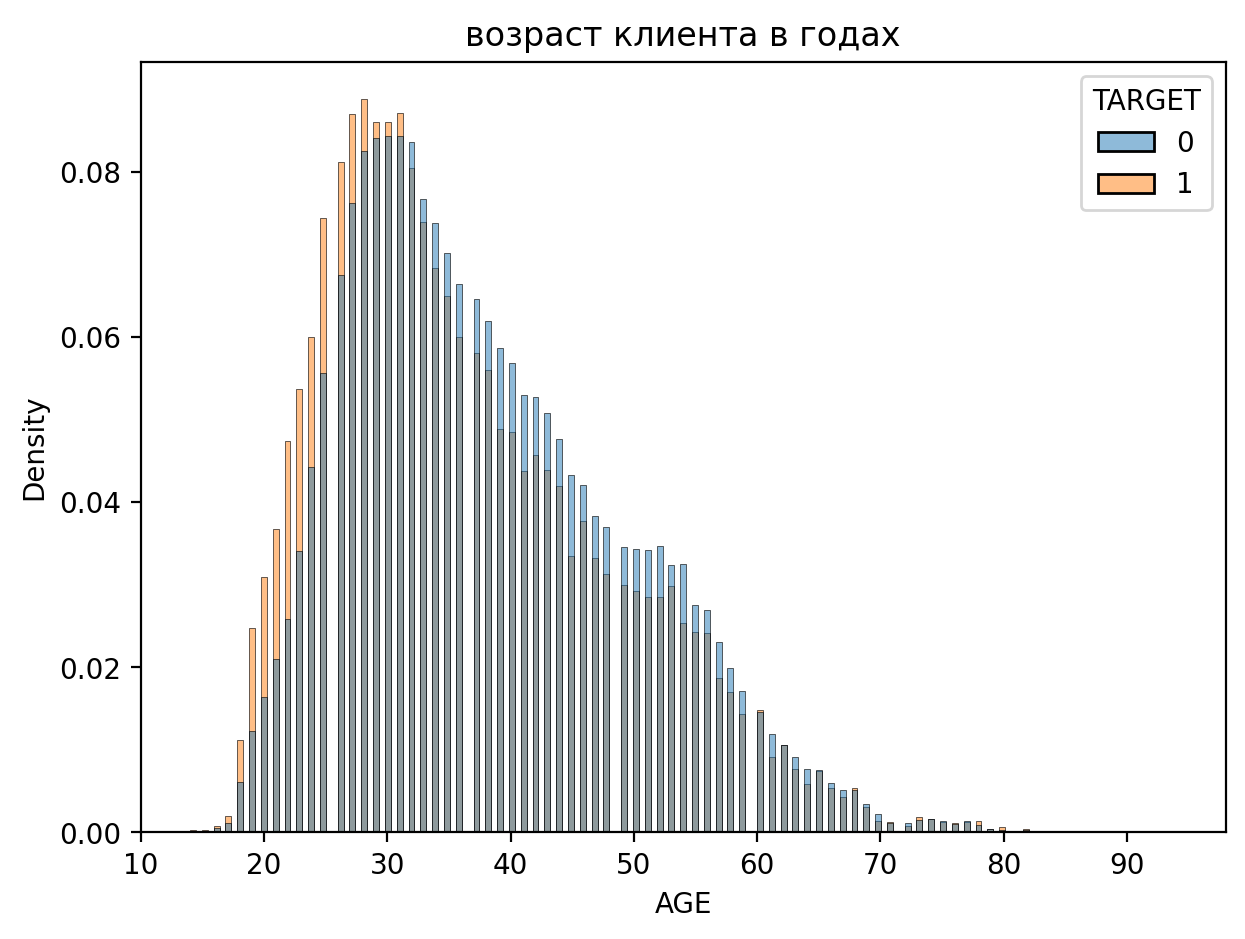

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.histplot(x=df['AGE']/12, hue=y, stat='density', common_norm=False)
plt.title('возраст клиента в годах')
plt.show()

fig.savefig(r'../imgs/age_dist.jpeg', dpi=300)

## наличие машины / водительских прав у клиентов

данные о наличии машины есть у 57.256 клиентов  
данные о наличии водительских прав есть у ровно такого же количества клиентов

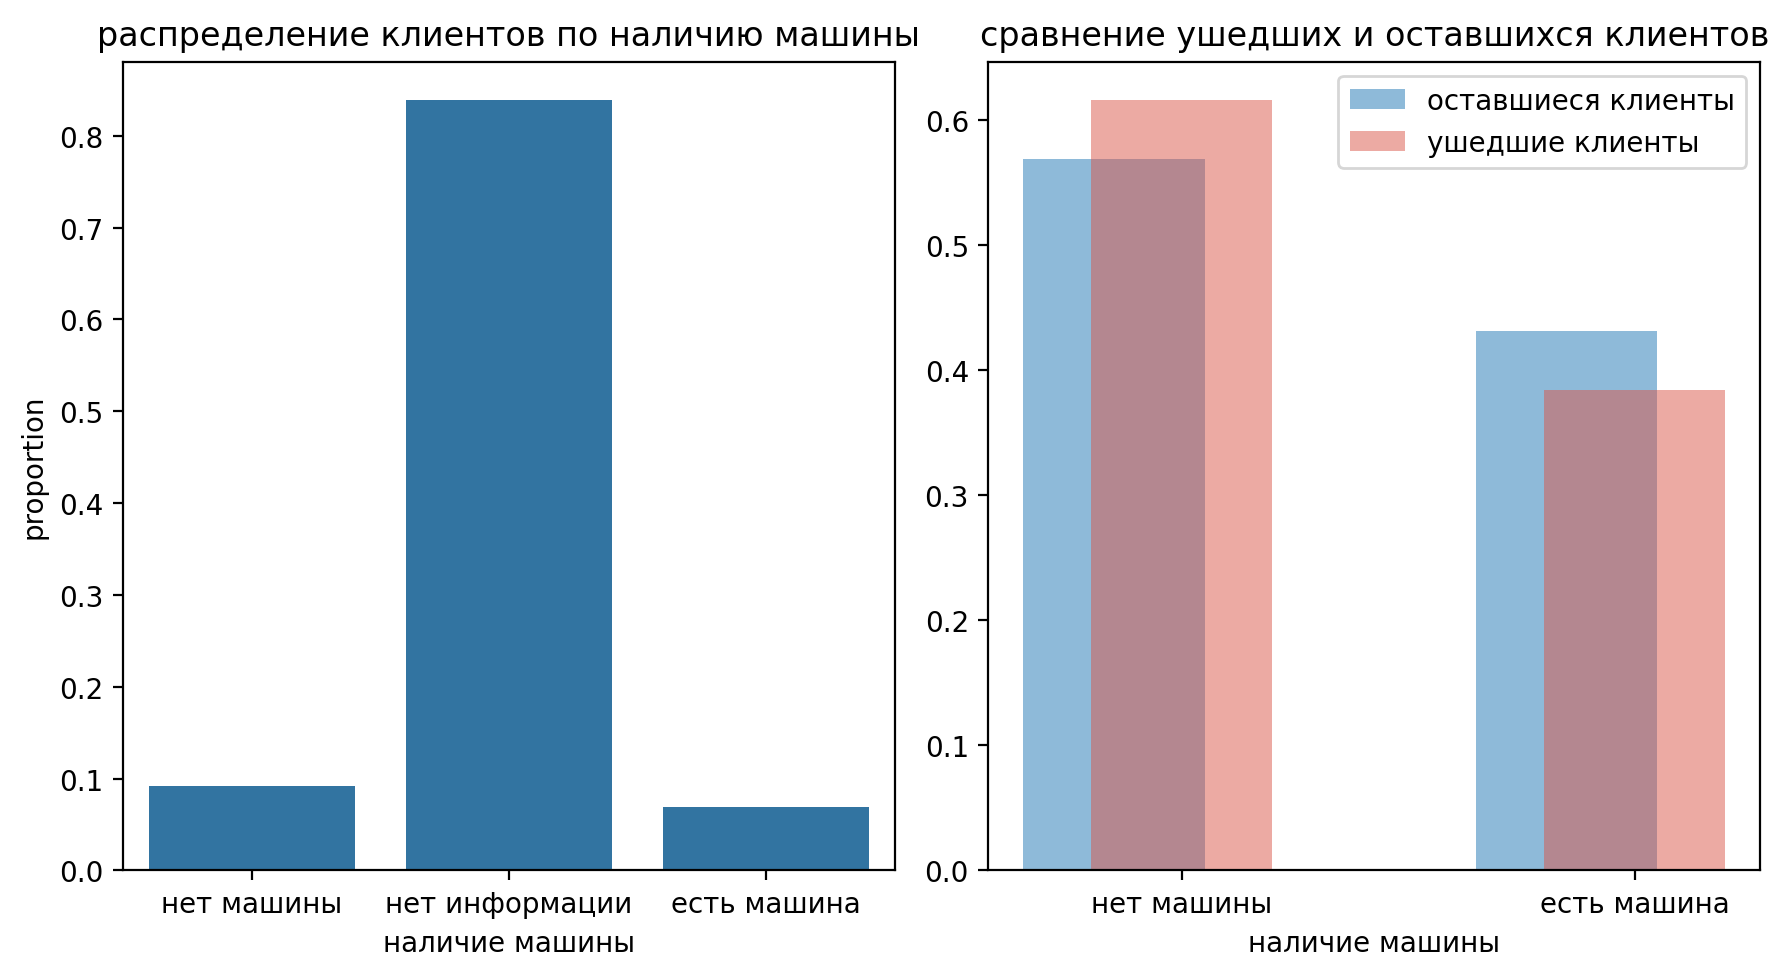

In [9]:
ef.plot_bin_bars(df, 
              y, 
              'APP_CAR', 
              'распределение клиентов по наличию машины', 
              'наличие машины', 
              ['нет машины', 'нет информации', 'есть машина'], 
              ['нет машины', 'есть машина'])

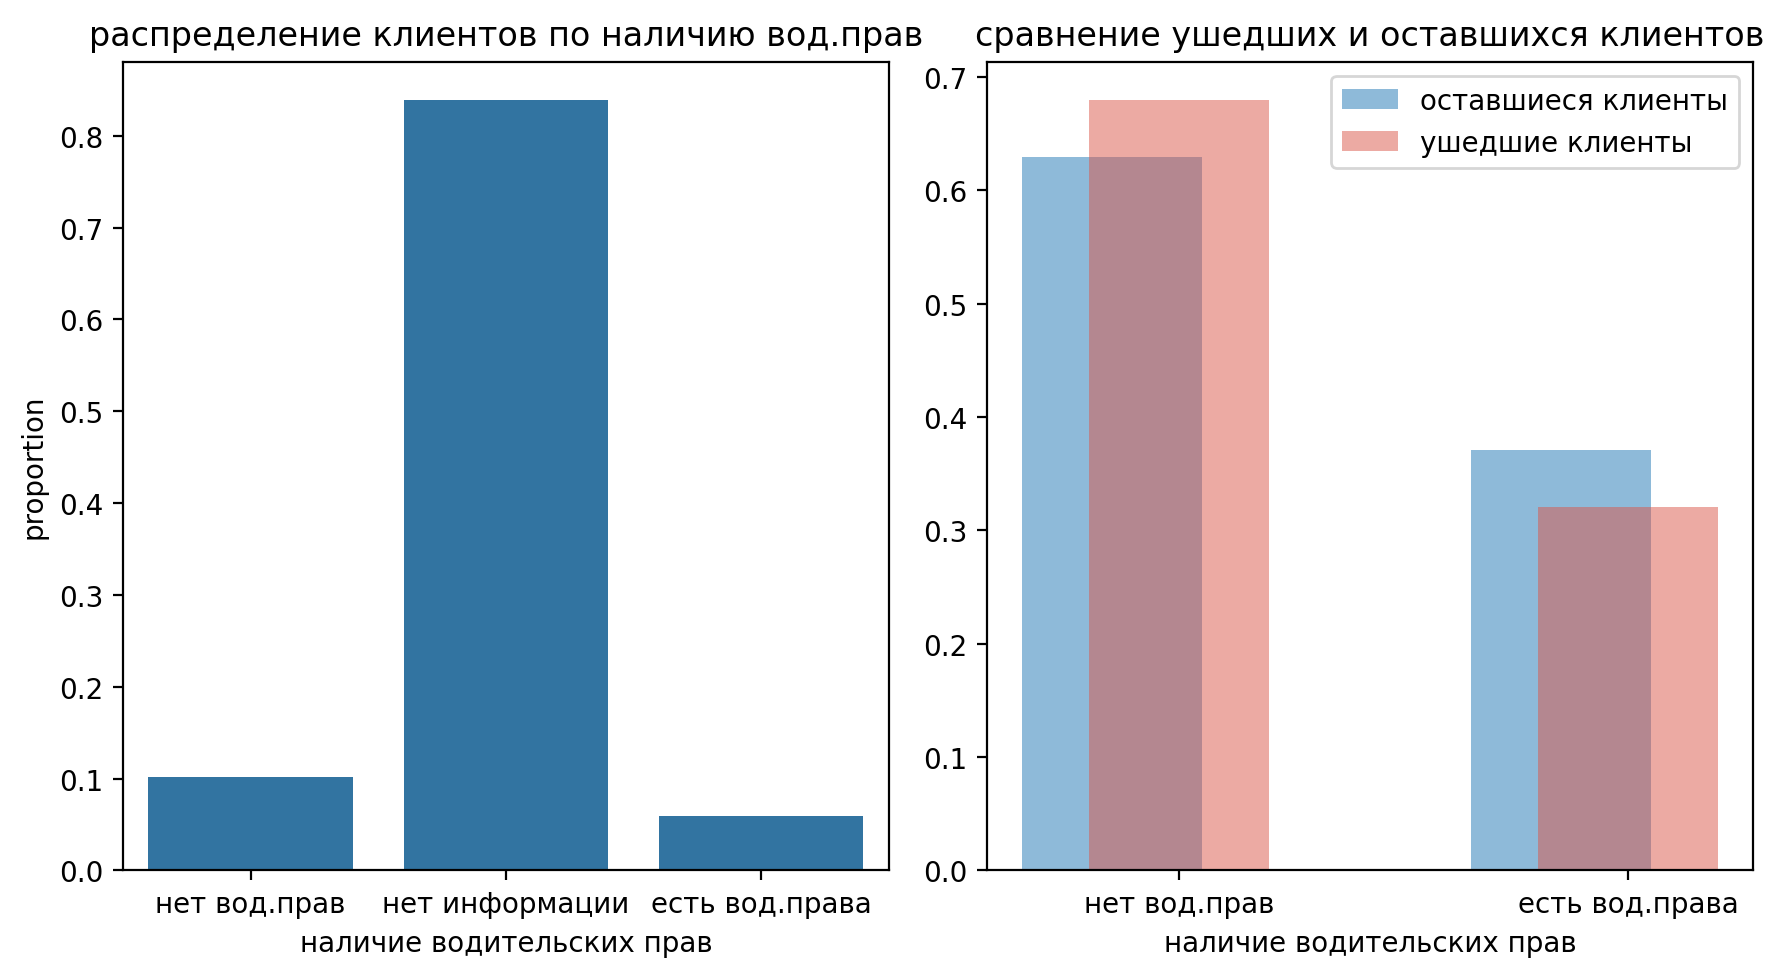

In [10]:
ef.plot_bin_bars(df, 
              y, 
              'APP_DRIVING_LICENSE', 
              'распределение клиентов по наличию вод.прав', 
              'наличие водительских прав', 
              ['нет вод.прав', 'нет информации', 'есть вод.права'], 
              ['нет вод.прав', 'есть вод.права'])

## наличие заграничного паспорта у клиентов

данные о наличии загран. паспорта аналогично есть у 57.256 клиентов   
и доли уходящих и остающихся клиетов примерно равны как для клиентов с загран. паспортом так и без

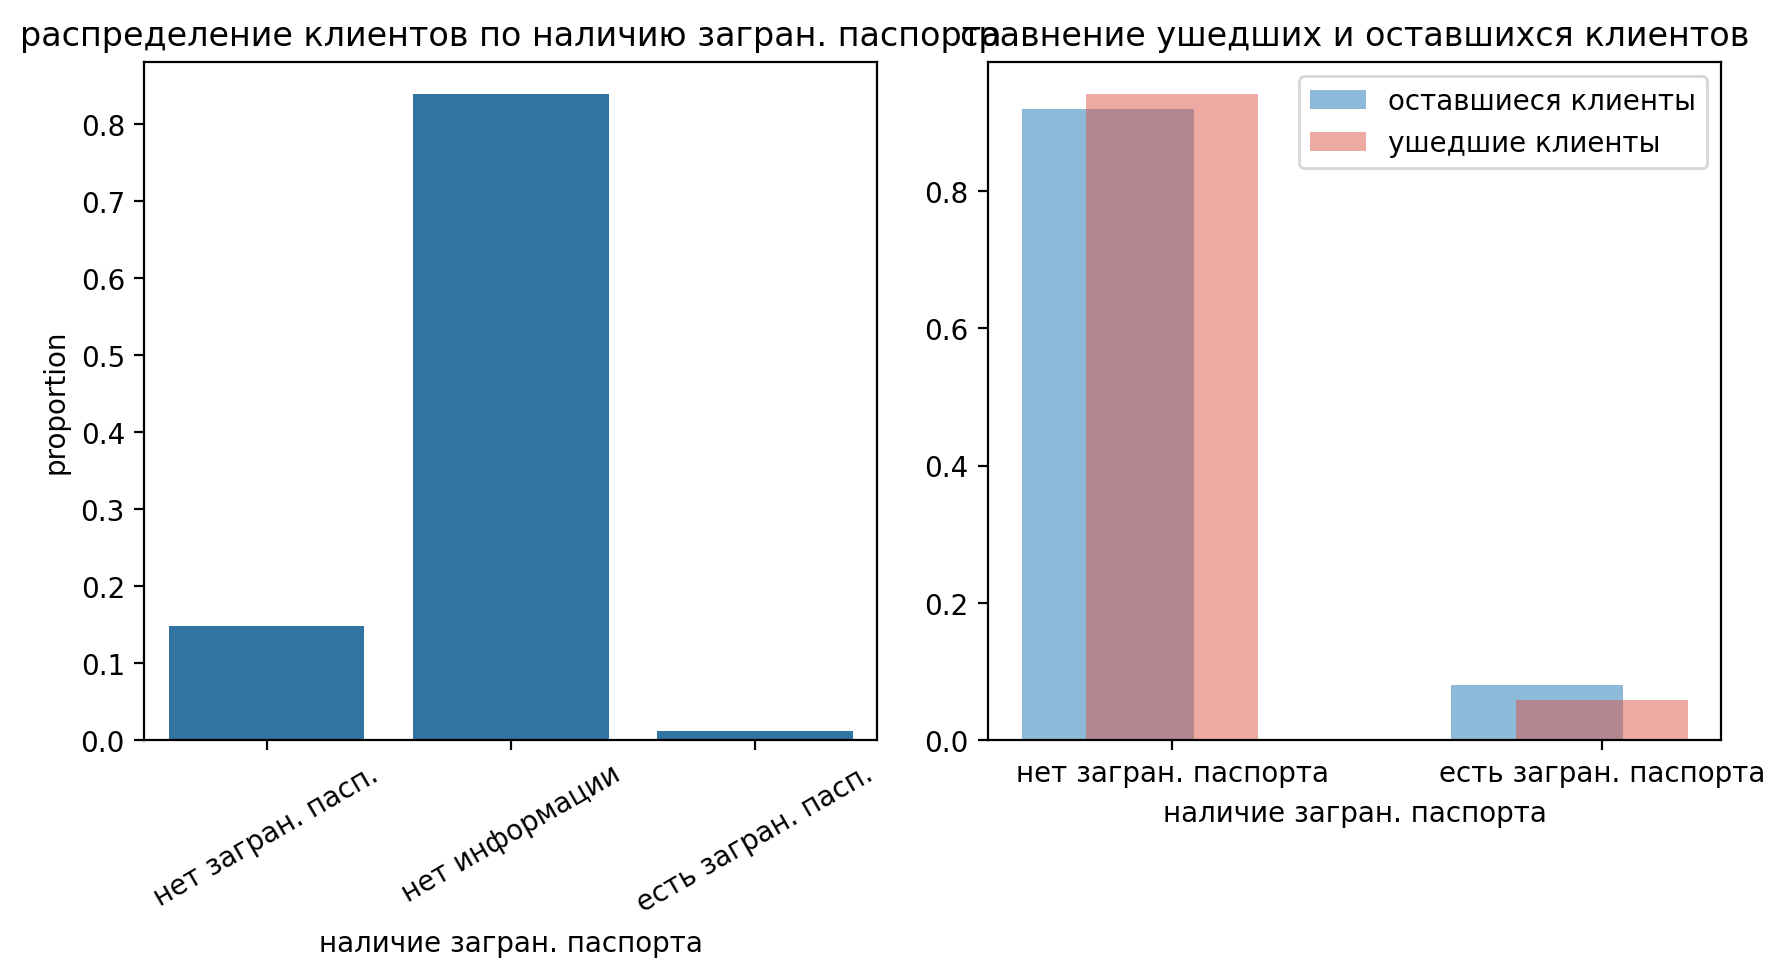

In [11]:
ef.plot_bin_bars(df, 
              y, 
              'APP_TRAVEL_PASS', 
              'распределение клиентов по наличию загран. паспорта', 
              'наличие загран. паспорта', 
              ['нет загран. пасп.', 'нет информации', 'есть загран. пасп.'], 
              ['нет загран. паспорта', 'есть загран. паспорта'],
              x1_rot=30)

## место работы клиентов: типы работодателей

всего в колонке 4 уникальных значения:    
- PRIVATE - частная компания
- STATE - государственная организация
- IP - индивидуальный предприниматель
- INTER - международная компания

колонки APP_COMP_TYPE и APP_EMP_TYPE имеют одинковые значения для всех наблюдений  
одну из них можно дропнуть
 

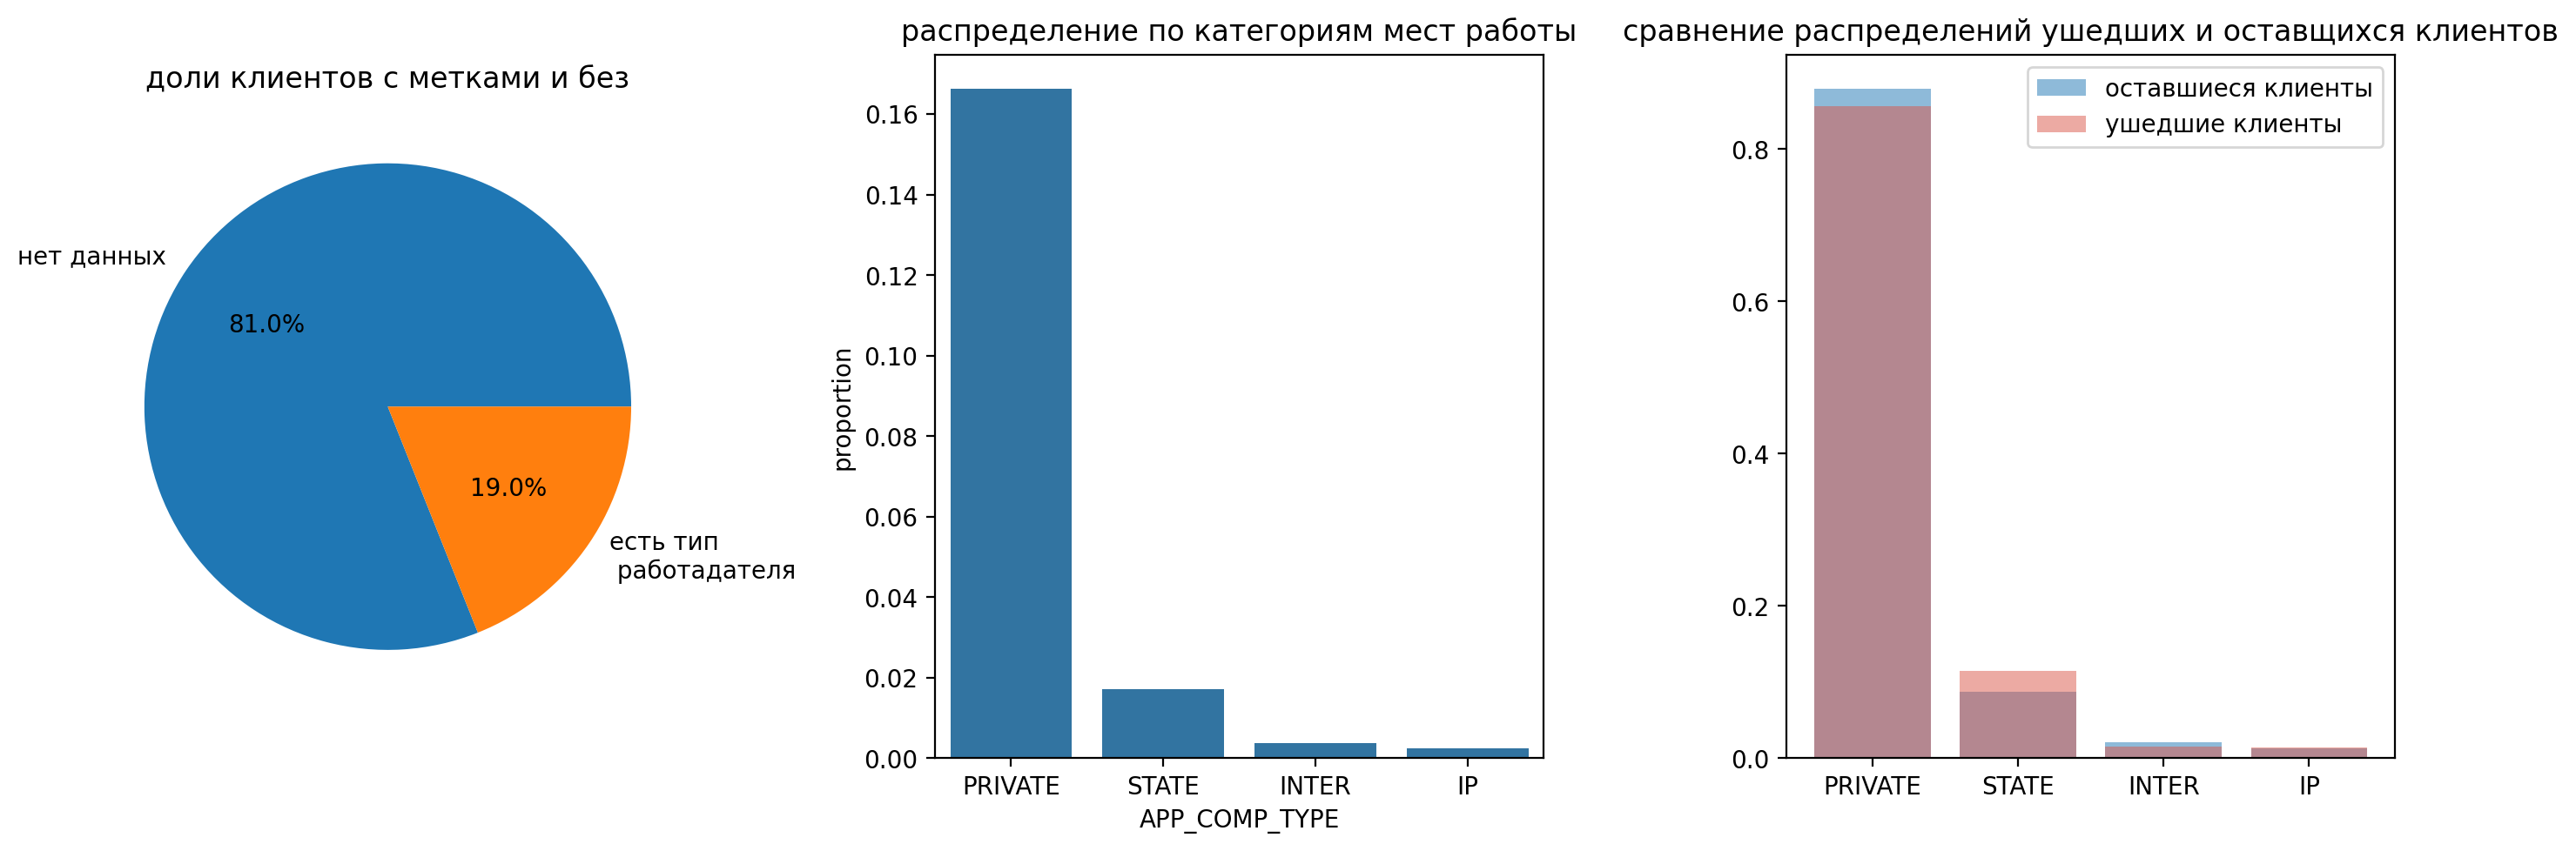

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14, 5))

count_na = df['APP_COMP_TYPE'].isna().sum()
count_ntna = df['APP_COMP_TYPE'].notna().sum()
ax[0].pie([count_na, count_ntna], labels=('нет данных', 'есть тип \n работадателя'),
        autopct='%1.1f%%')
ax[0].set_title('доли клиентов с метками и без')

bar1 = df['APP_COMP_TYPE'].value_counts(normalize=True, dropna=False)
sns.barplot(bar1, ax=ax[1])
ax[1].set_title('распределение по категориям мест работы')

bar1 = df['APP_COMP_TYPE'][y==0].value_counts(normalize=True)
bar2 = df['APP_COMP_TYPE'][y==1].value_counts(normalize=True)
ax[2].bar(bar1.index, bar1.values, alpha=0.5, label='оставшиеся клиенты')
ax[2].bar(bar2.index, bar2.values, alpha=0.5, label='ушедшие клиенты', color='#db5649')
ax[2].legend()
ax[2].set_title('сравнение распределений ушедших и оставщихся клиентов')

plt.tight_layout()
plt.show()

## типы пакетов услуг клиентов

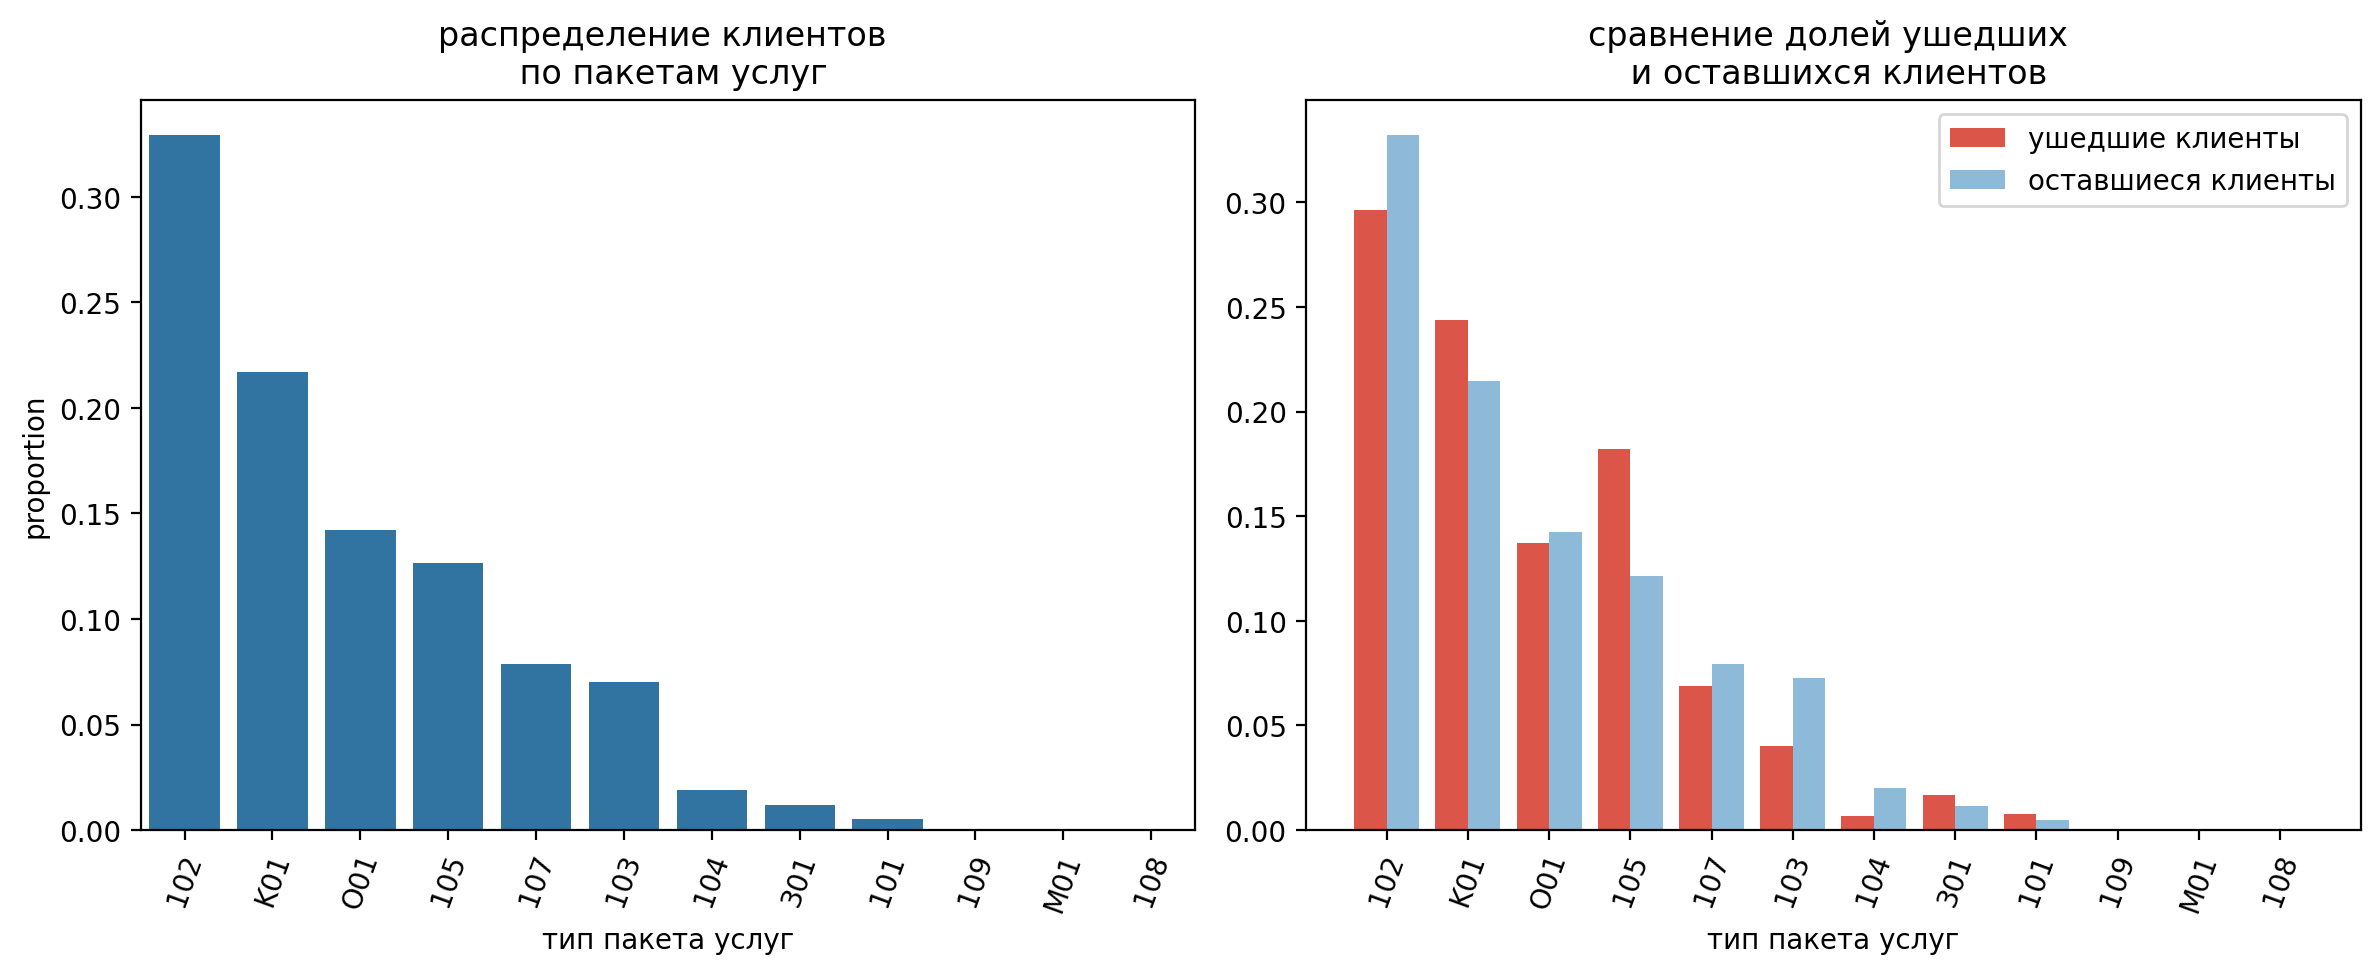

In [13]:
ef.plot_2_barplots(df, y, 'PACK', 'распределение клиентов \n по пакетам услуг', 'тип пакета услуг')

## уровень образования клиентов

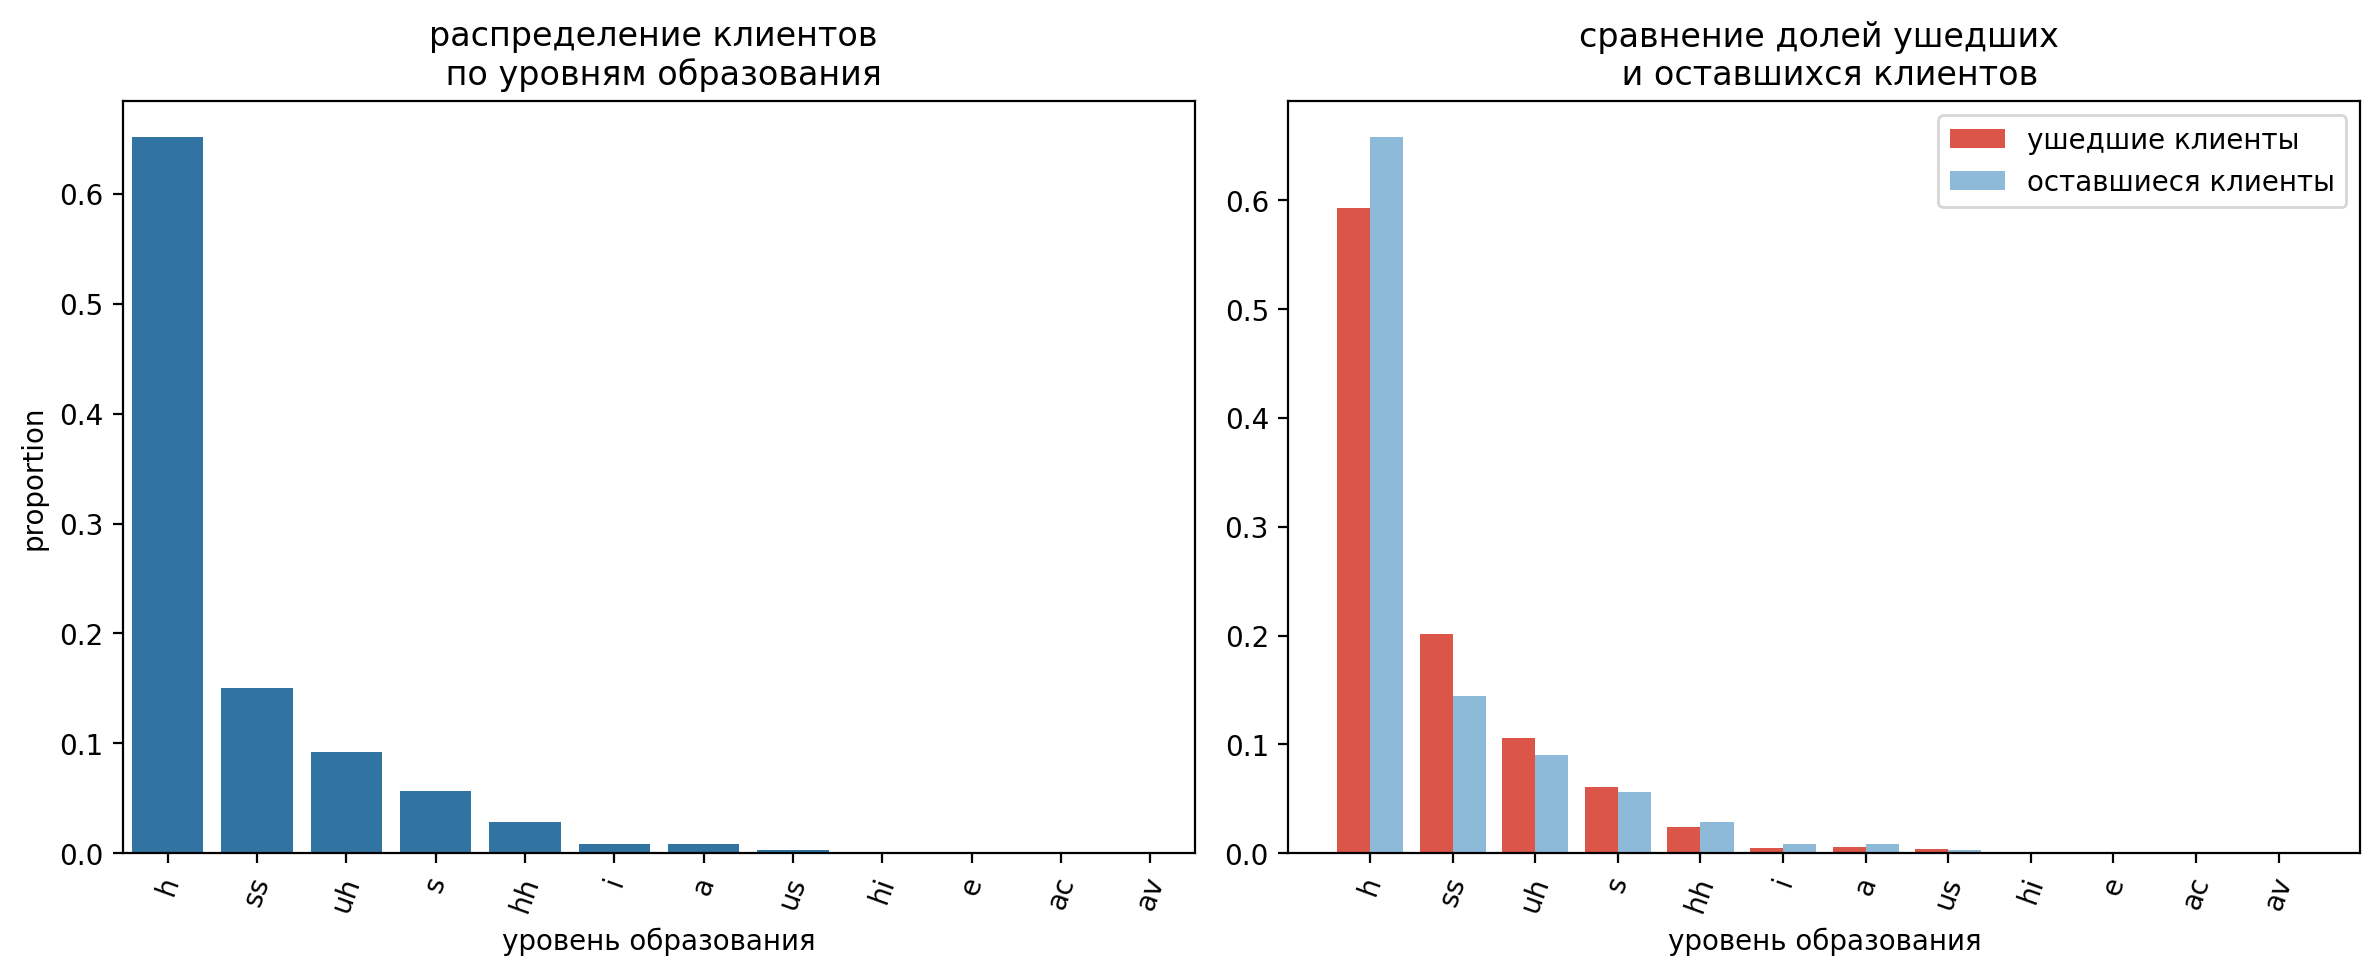

In [14]:
df['APP_EDUCATION'] = df['APP_EDUCATION'].str.lower()

ef.plot_2_barplots(df, y, 'APP_EDUCATION', 'распределение клиентов \n по уровням образования', 'уровень образования')

## категории должностей

колонки 'APP_POSITION_TYPE' и 'CLNT_JOB_POSITION_TYPE' имеют одинаковый состав  
в дальнейшей работе одну из колонок можно удалить

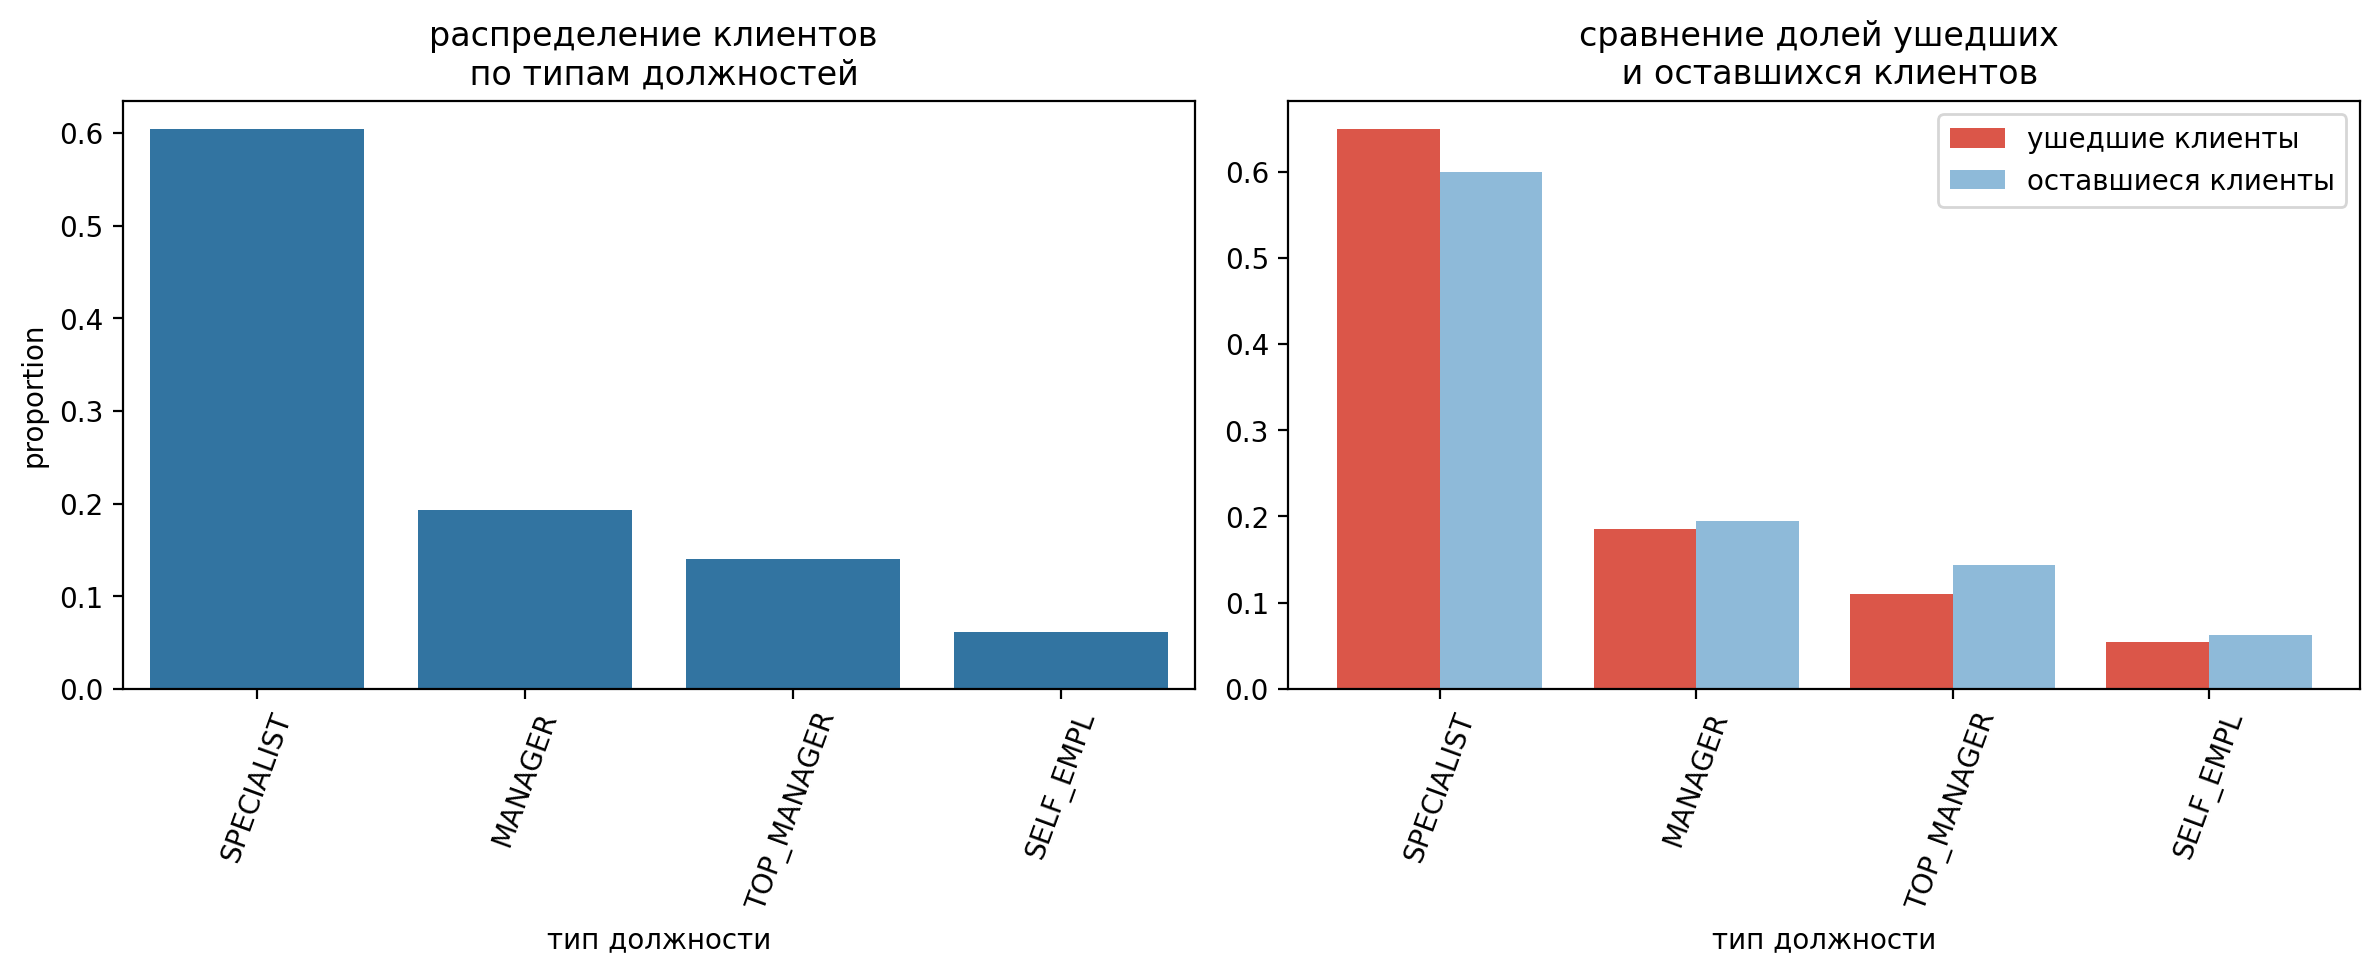

In [15]:
ef.plot_2_barplots(df, y, 'APP_POSITION_TYPE', 'распределение клиентов \n по типам должностей', 'тип должности')

## тип должности/профессии клиентов

очень много профессий  
професии написаны всеми возможными способами, со всеми возможными ошибками    
(пример: юрист-консультант, юрист-консультанат, юрист-консульт, юрист-консул, юрист- консульт, юрист,  помощник нотариуса, юрист по недвижимости, юрист по корпоративным вопросам, юрист конусульт, юрист консультант, юрист консульт, юрист консул, юрист колсульт, юрист вэд, юрист ведущий, юрист -консульт, юрист, юрисконсультант, юрисконсульт по междун.вопросам, юрисконсульт 1-й категории, юрисконсульт, юрисконсуль., юрисконсуль, юрисконсулт, юрисконсул, юрисn-консульт, юрис-консульт, юрис консульт)  

В исходной выборке 19588 штук уникальных значений профессий.  
Текущая обработка уменьшает количество уникальных значений до 9000


In [16]:
def clean_text(text_i):
    text_i = str(text_i)
    text_i = text_i.strip()
    text_i = re.sub('ё', 'е', text_i)
    text_i = re.sub('/d+', '', text_i)
    return text_i

In [17]:
def normalize_job_names(df):
    dfc = df.copy()
    col = 'CLNT_JOB_POSITION'
    dfc[col] = dfc[col].str.lower()

    cond_3 = dfc[col].str.contains('зам')
    dfc.loc[cond_3, col] = 'заместитель'
    
    cond_1 = dfc[col].str.contains('нач')
    dfc.loc[cond_1, col] = 'начальник'

    cond_2 = dfc[col].str.contains('директ')
    dfc.loc[cond_2, col] = 'директор'

    cond_4 = dfc[col].str.contains('пом')
    dfc.loc[cond_4, col] = 'помощник'

    cond_5 = dfc[col].str.contains('менед')
    dfc.loc[cond_5, col] = 'менеджер'

    cond_5 = dfc[col].str.contains('руков')
    dfc.loc[cond_5, col] = 'руководитель'

    cond_5 = dfc[col].str.contains('инж')
    dfc.loc[cond_5, col] = 'инженер'

    return dfc

In [18]:
dfc = df.copy()
dfc['CLNT_JOB_POSITION'] = dfc['CLNT_JOB_POSITION'][dfc['CLNT_JOB_POSITION'].notna()].apply(clean_text)

dfc = normalize_job_names(dfc)
dfc['CLNT_JOB_POSITION'].value_counts()

CLNT_JOB_POSITION
директор                         47735
менеджер                         22692
заместитель                      11668
инженер                           9996
руководитель                      9126
                                 ...  
эл.газосварщик                       1
офисный водитель                     1
эксперт контакт центра               1
прохлдчик                            1
художник компьютерной графики        1
Name: count, Length: 8783, dtype: int64

## жилищные условия клиентов

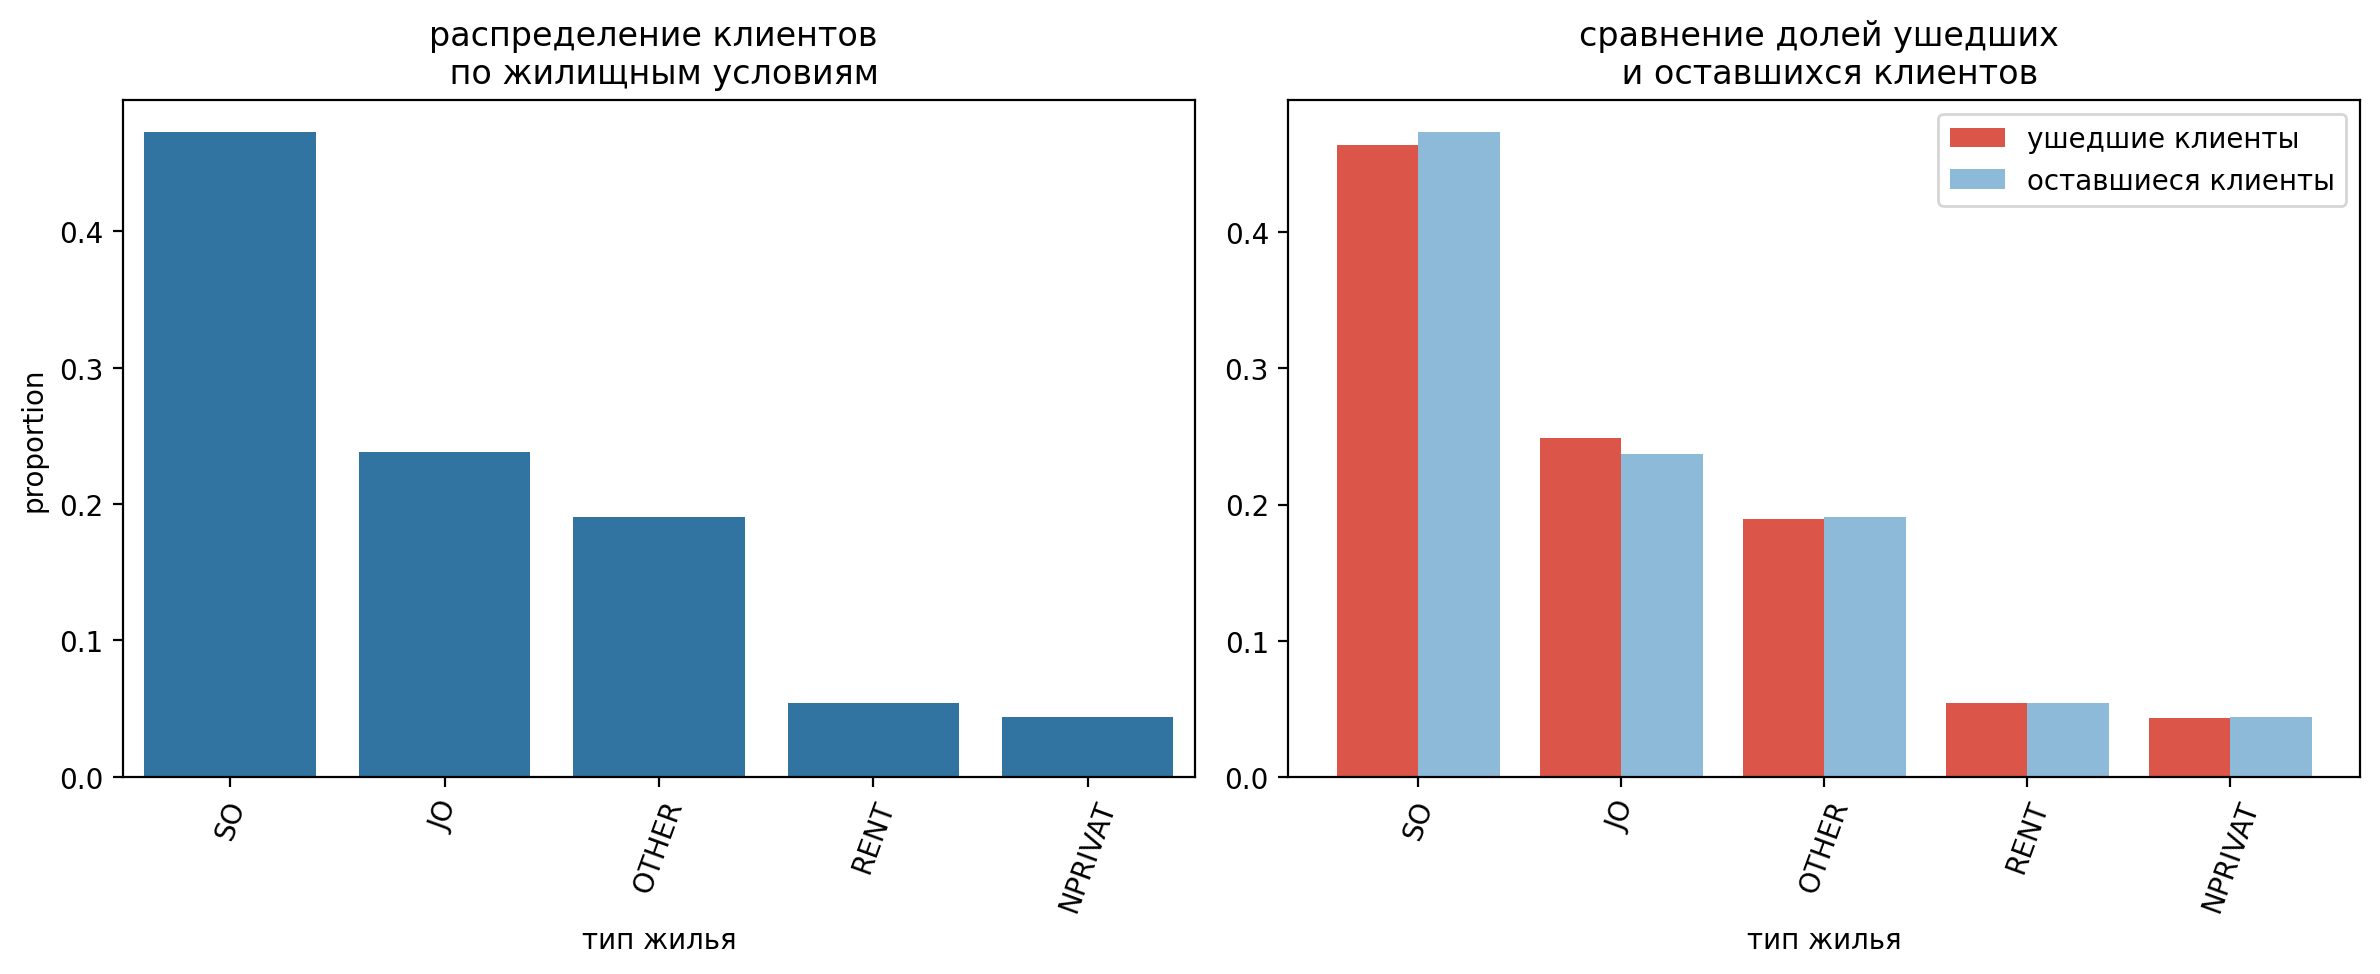

In [19]:
ef.plot_2_barplots(df, y, 'APP_KIND_OF_PROP_HABITATION', 'распределение клиентов \n по жилищным условиям', 'тип жилья')

## семейное положение клиентов

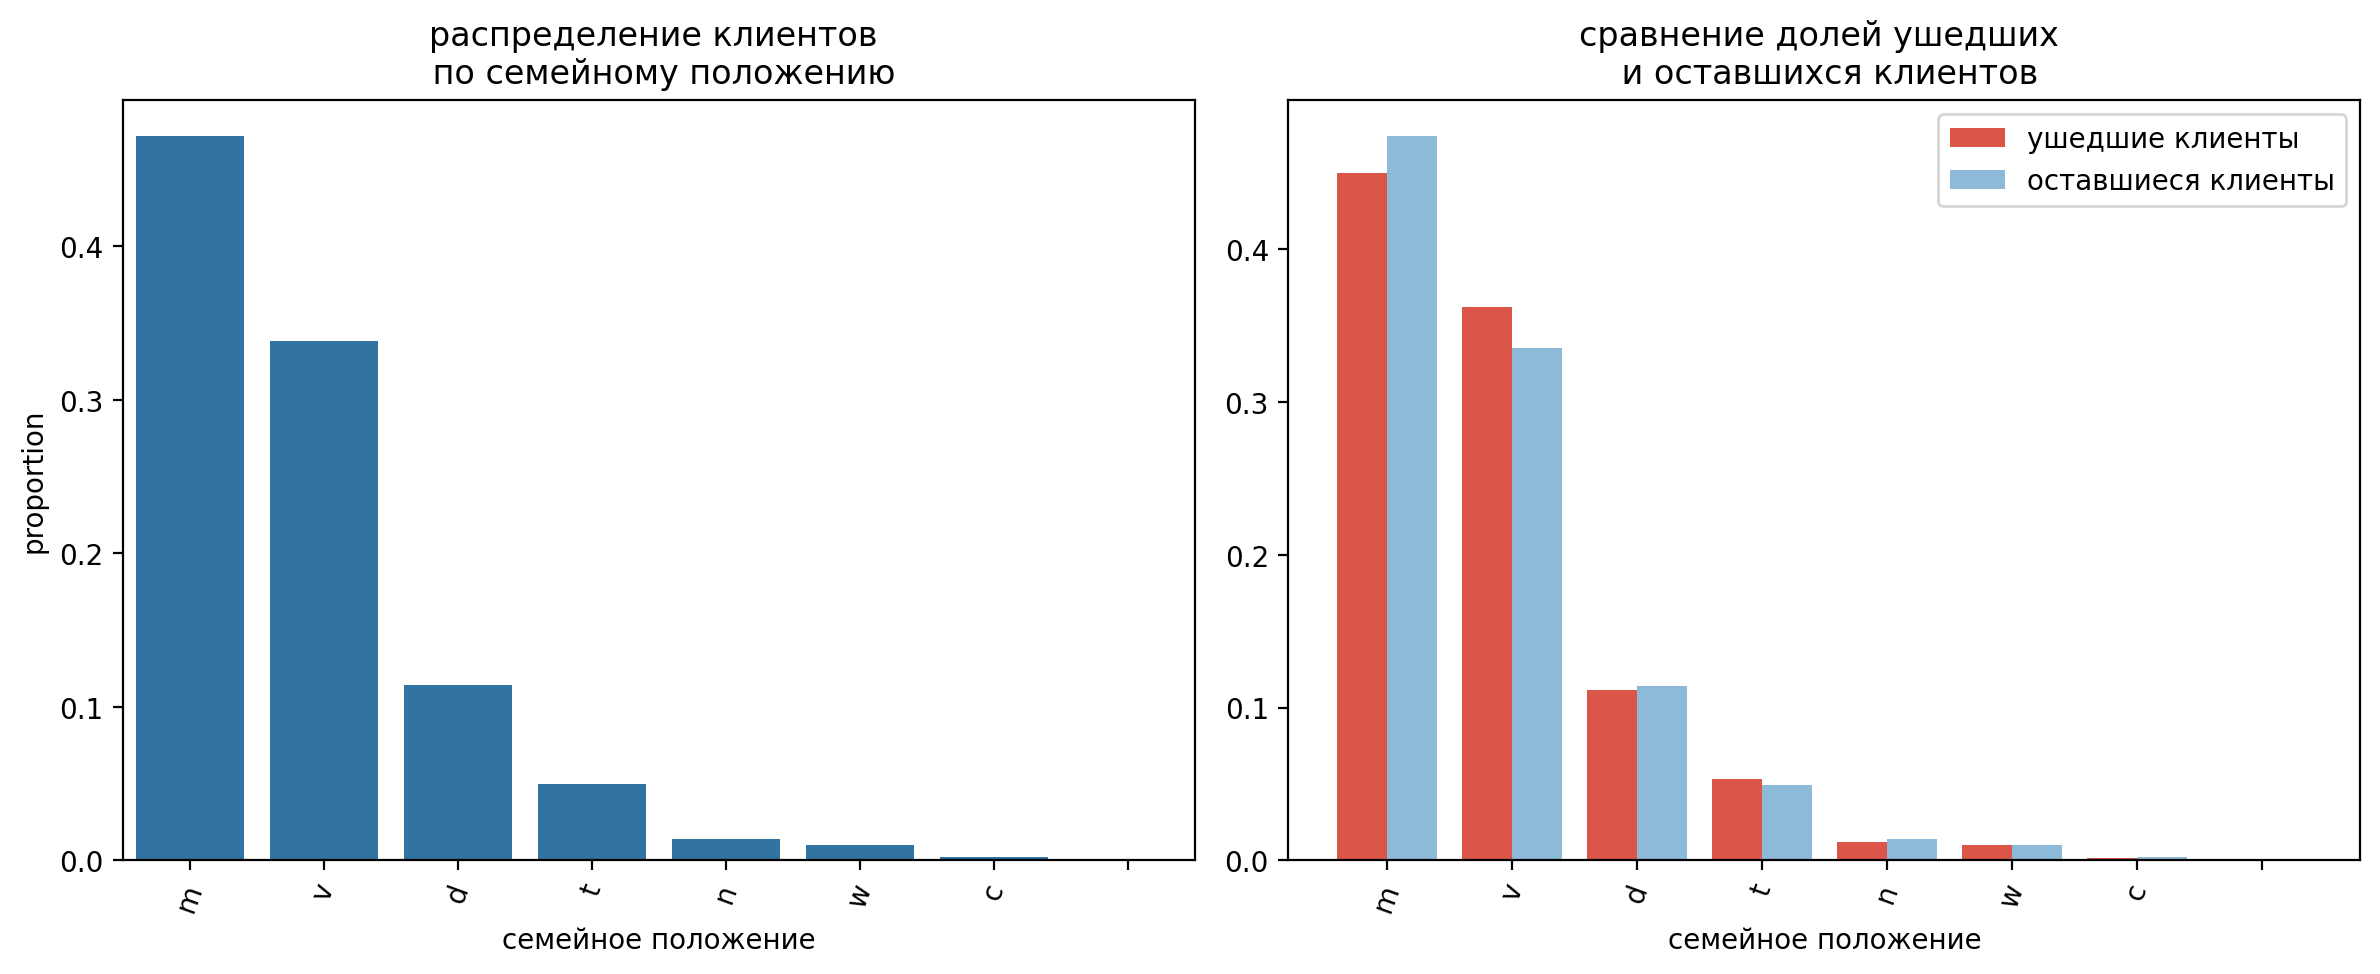

In [20]:
df['APP_MARITAL_STATUS'] = df['APP_MARITAL_STATUS'].str.lower()

ef.plot_2_barplots(df, y, 'APP_MARITAL_STATUS', 'распределение клиентов \n по семейному положению', 'семейное положение')

## ближайшее доверенное лицо клиента перед банком

In [21]:
col = 'CLNT_TRUST_RELATION'
df[col] = df[col].str.lower()
relatives_dict = {'сын':'son', 'близкий ро':'relative', 'друг':'friend',
                  'отец': 'father', 'сестра': 'sister', 'мать': 'mother', 
                  'муж': 'husband', 'брат': 'brother', 'дальний ро': 'relative', 
                  'дочь': 'daughter', 'жена':'wife'}
df[col] = df[col].replace(relatives_dict)
df[col] = df[col].fillna('missing')

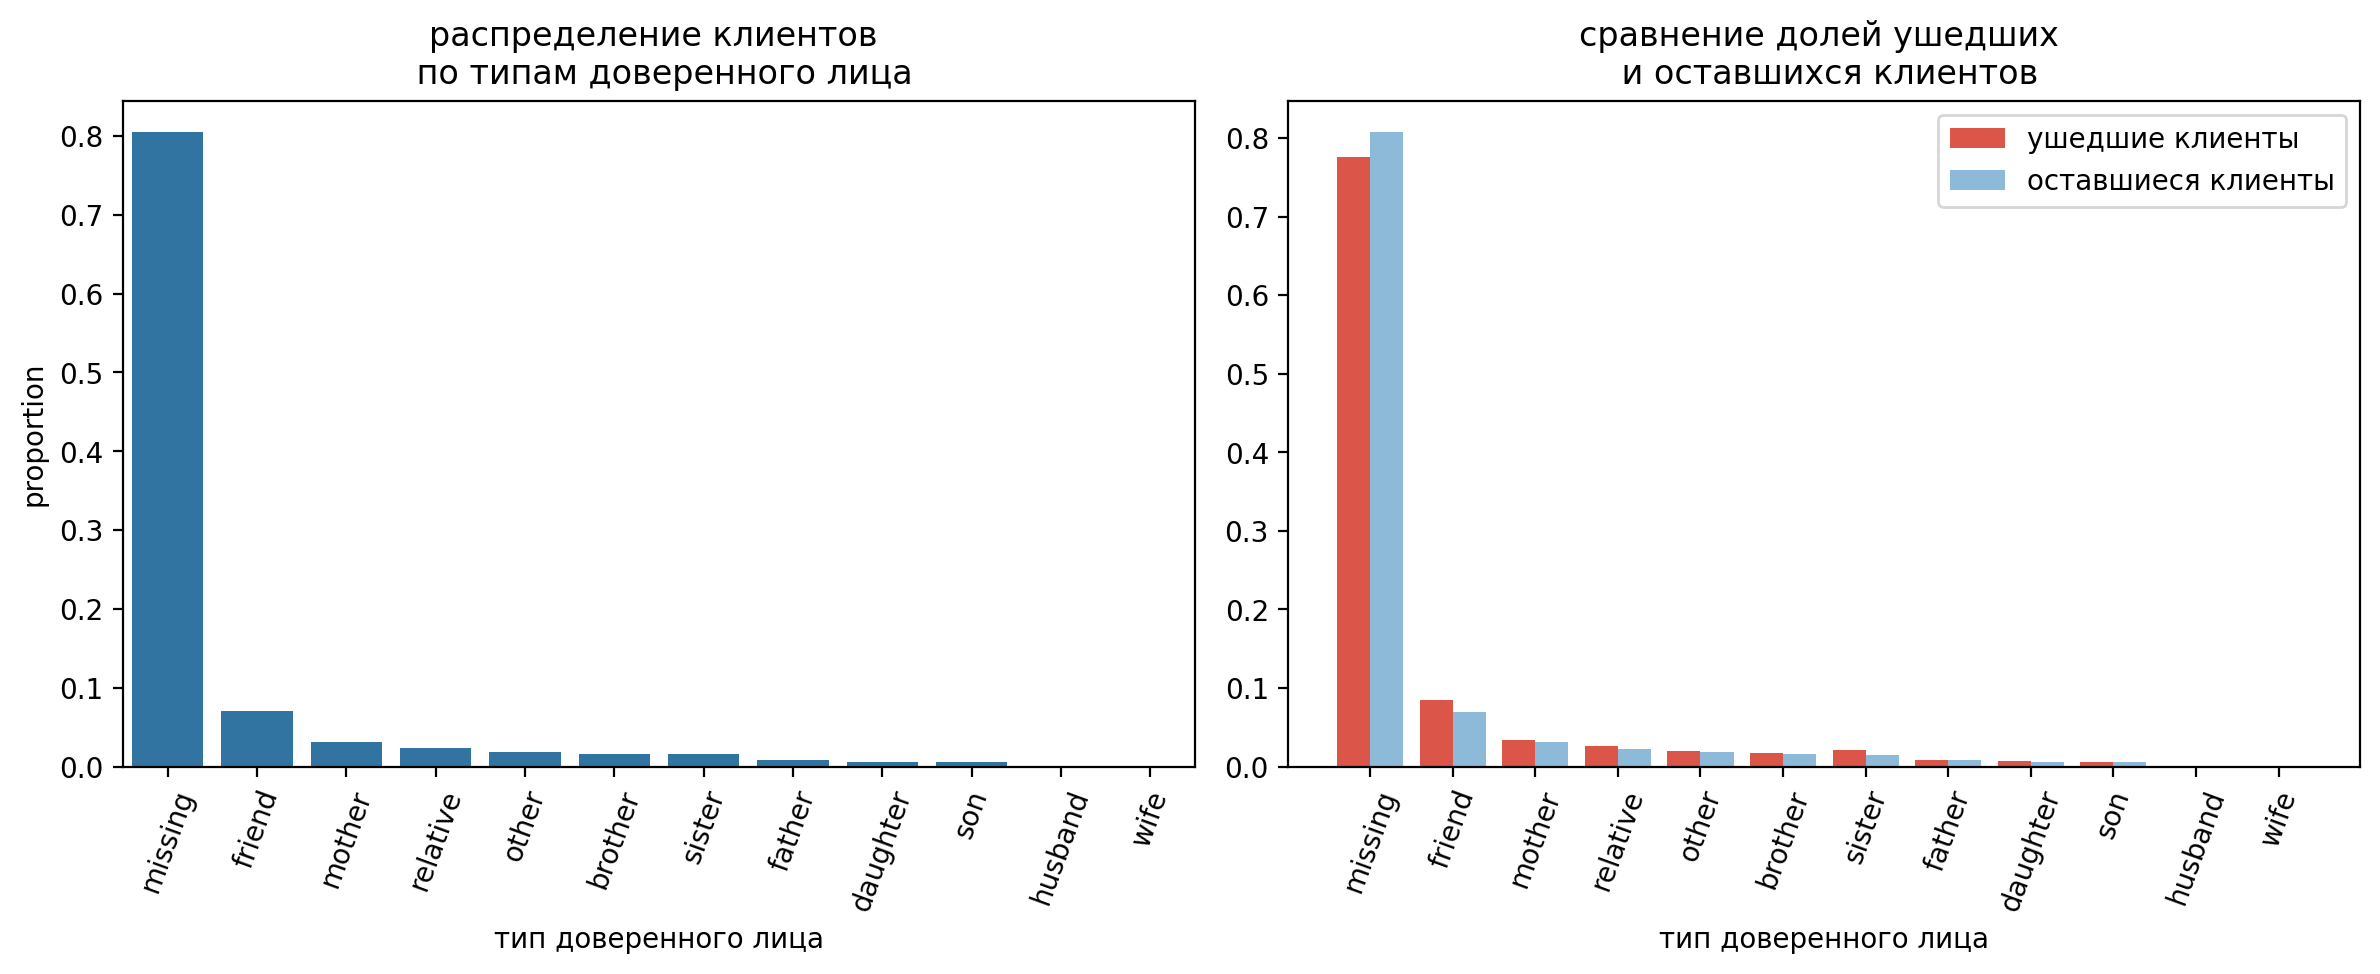

In [22]:
ef.plot_2_barplots(df, y, 'CLNT_TRUST_RELATION', 'распределение клиентов \n по типам доверенного лица', 'тип доверенного лица')

## средний оборот по зарплатным счетам

- клиенты, у которых средний оборот средств на зарплатном счете находится в диапазоне $10^3 - 10^5$ условных единиц чаще уходили от банка
- клиенты с оборотом средств в диапазоне $10^5 - 10^7$ у.е. реже уходили из банка

c:\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


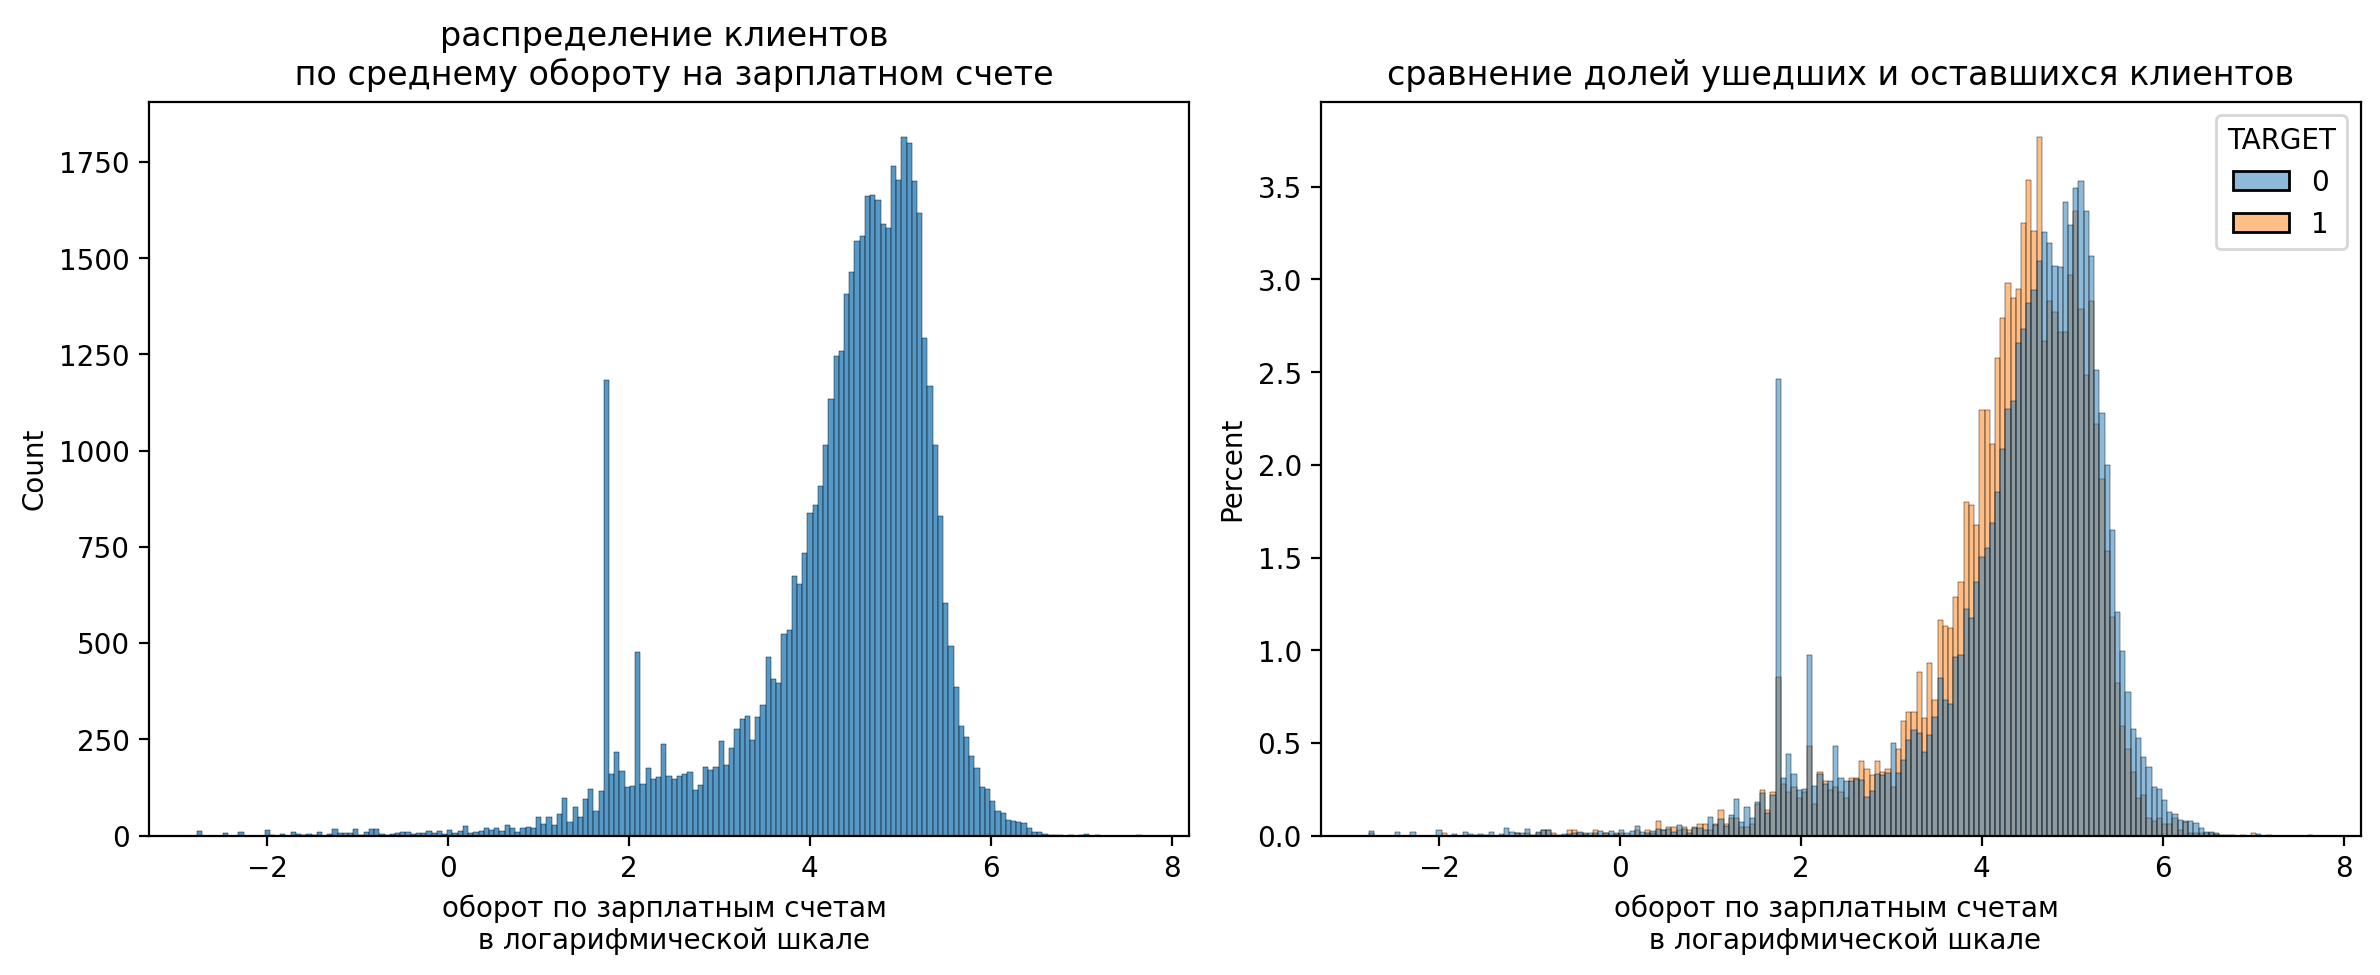

In [23]:
ef.plot_2_hists(df, y,
             'TURNOVER_PAYM', 
             'распределение клиентов \n по среднему обороту на зарплатном счете', 
             'оборот по зарплатным счетам \n в логарифмической шкале', 
             log=True
)

## cредний оборот по кредитным картам

c:\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


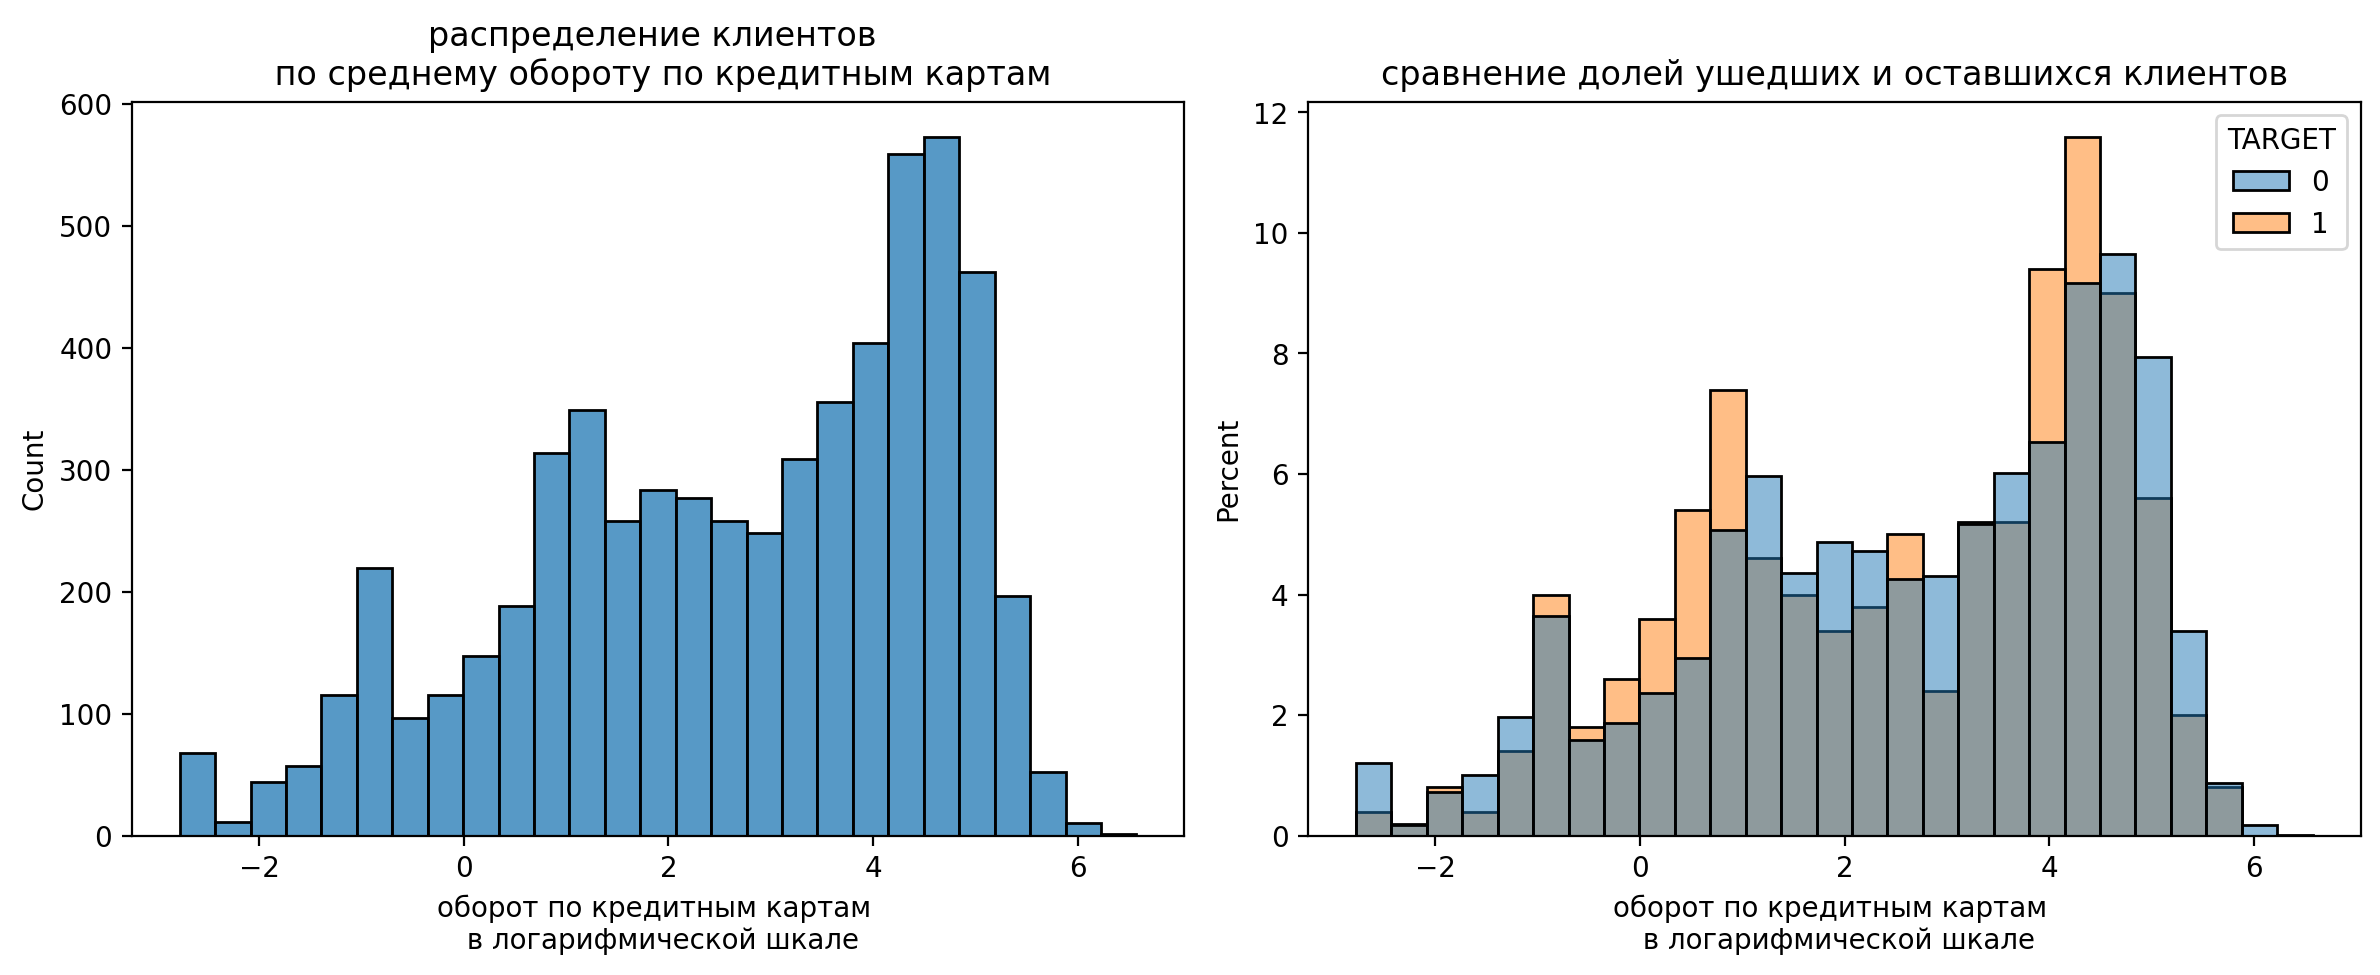

In [24]:
ef.plot_2_hists(df, y,
             'TURNOVER_CC', 
             'распределение клиентов \n по среднему обороту по кредитным картам', 
             'оборот по кредитным картам \n в логарифмической шкале', 
             log=True)

##  средний остаток на зарплатных счетах

c:\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


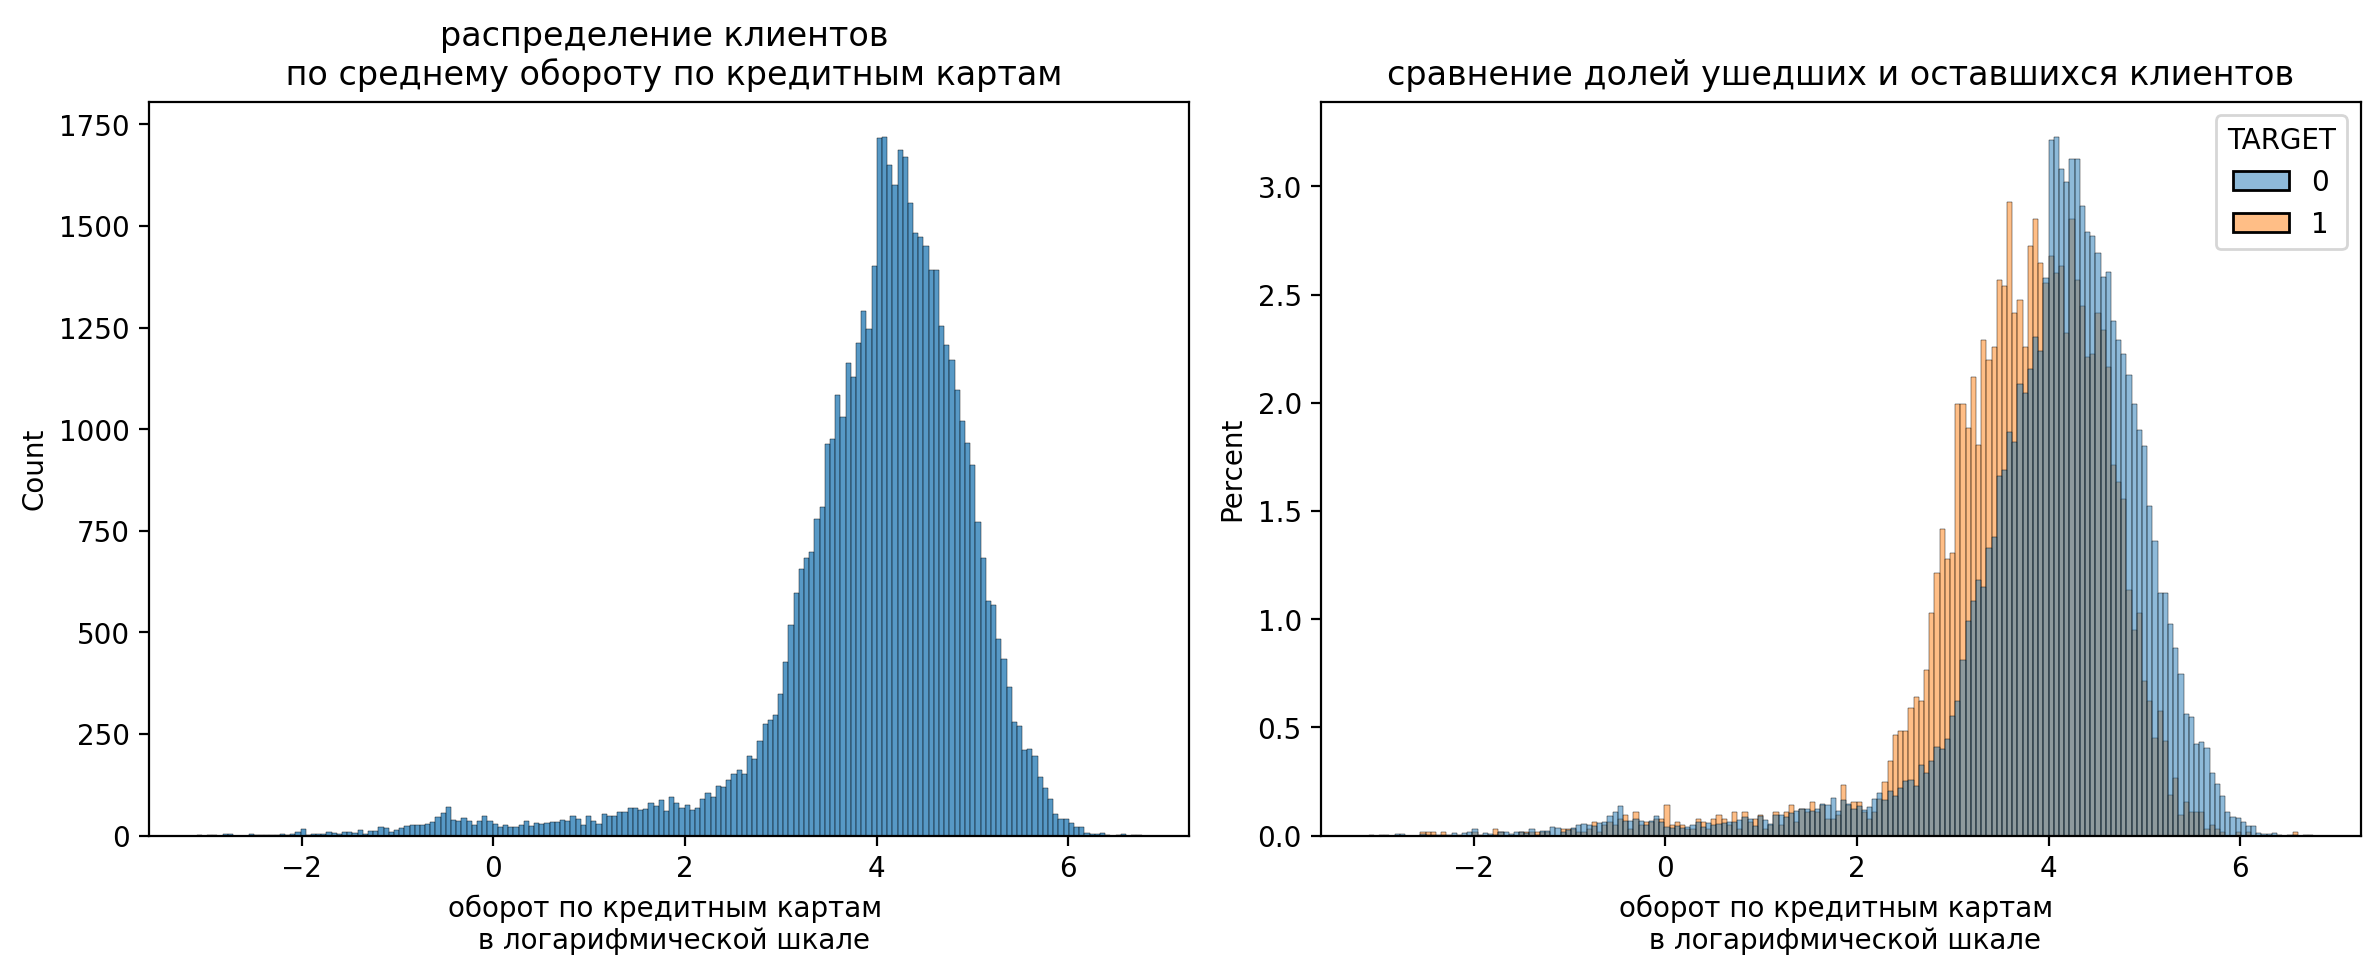

In [25]:
ef.plot_2_hists(df, y,
             'REST_AVG_PAYM', 
             'распределение клиентов \n по среднему обороту по кредитным картам', 
             'оборот по кредитным картам \n в логарифмической шкале', 
             log=True)

## средние остатки денежных средств на текущем счете

c:\Python311\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


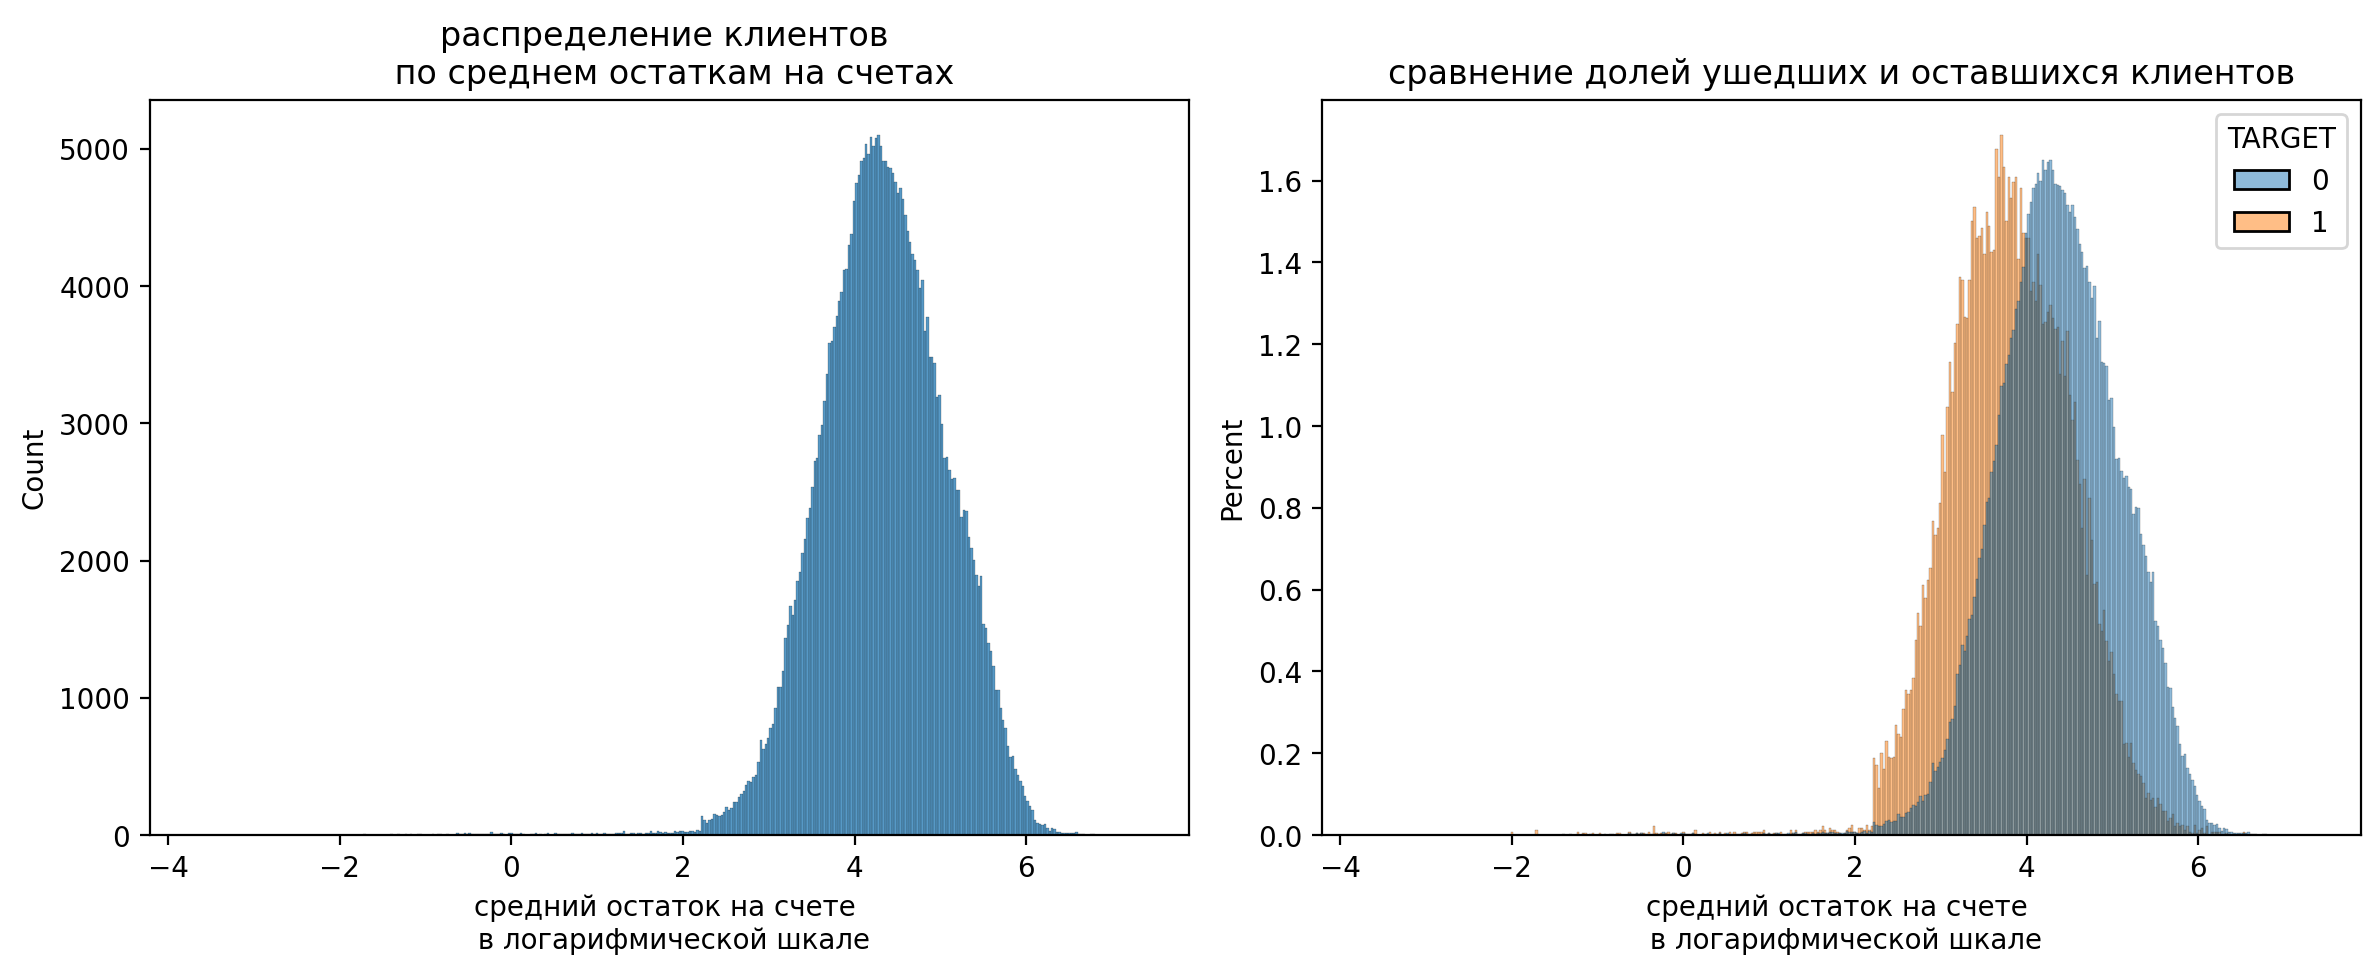

In [26]:
ef.plot_2_hists(df, y,
             'REST_AVG_CUR', 
             'распределение клиентов \n по среднем остаткам на счетах', 
             'средний остаток на счете \n в логарифмической шкале', 
             log=True)

##

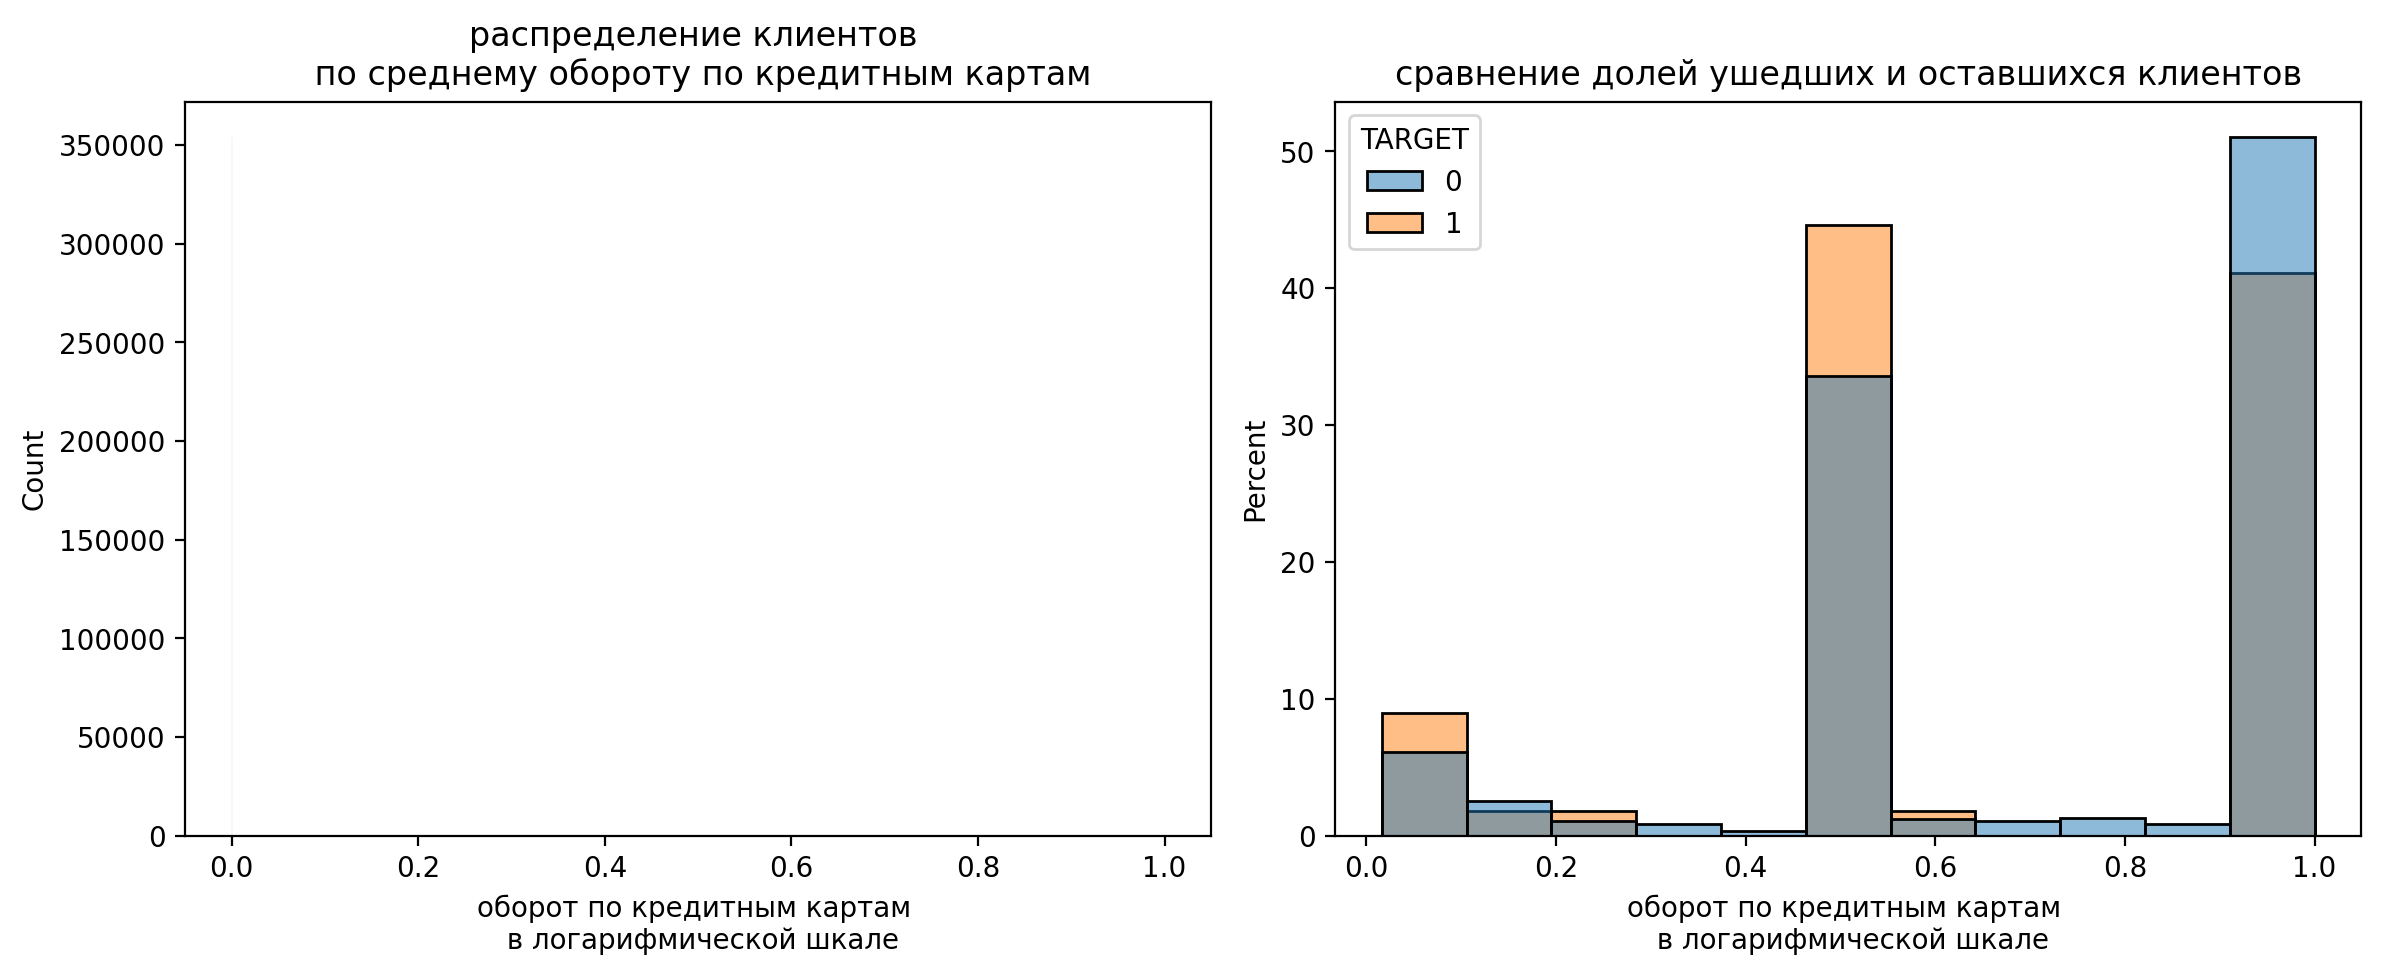

In [27]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
bar_col = 'LDEAL_GRACE_DAYS_PCT_MED'

sns.histplot((df[bar_col]), ax=ax[0])
ax[0].set_title('распределение клиентов \n по среднему обороту по кредитным картам')
ax[0].set_xlabel('оборот по кредитным картам \n в логарифмической шкале')

plot_data = df[bar_col][df[bar_col]>0]
plot_data = (plot_data)
sns.histplot(x=plot_data, hue=y, ax=ax[1], stat='percent', common_norm=None)
ax[1].set_title('сравнение долей ушедших и оставшихся клиентов')
ax[1].set_xlabel('оборот по кредитным картам \n в логарифмической шкале')

plt.tight_layout()
plt.show()

## Срок обслуживания клиента

- чаще уходят клиенты которые обслуживаются банком менее 4 месяцев

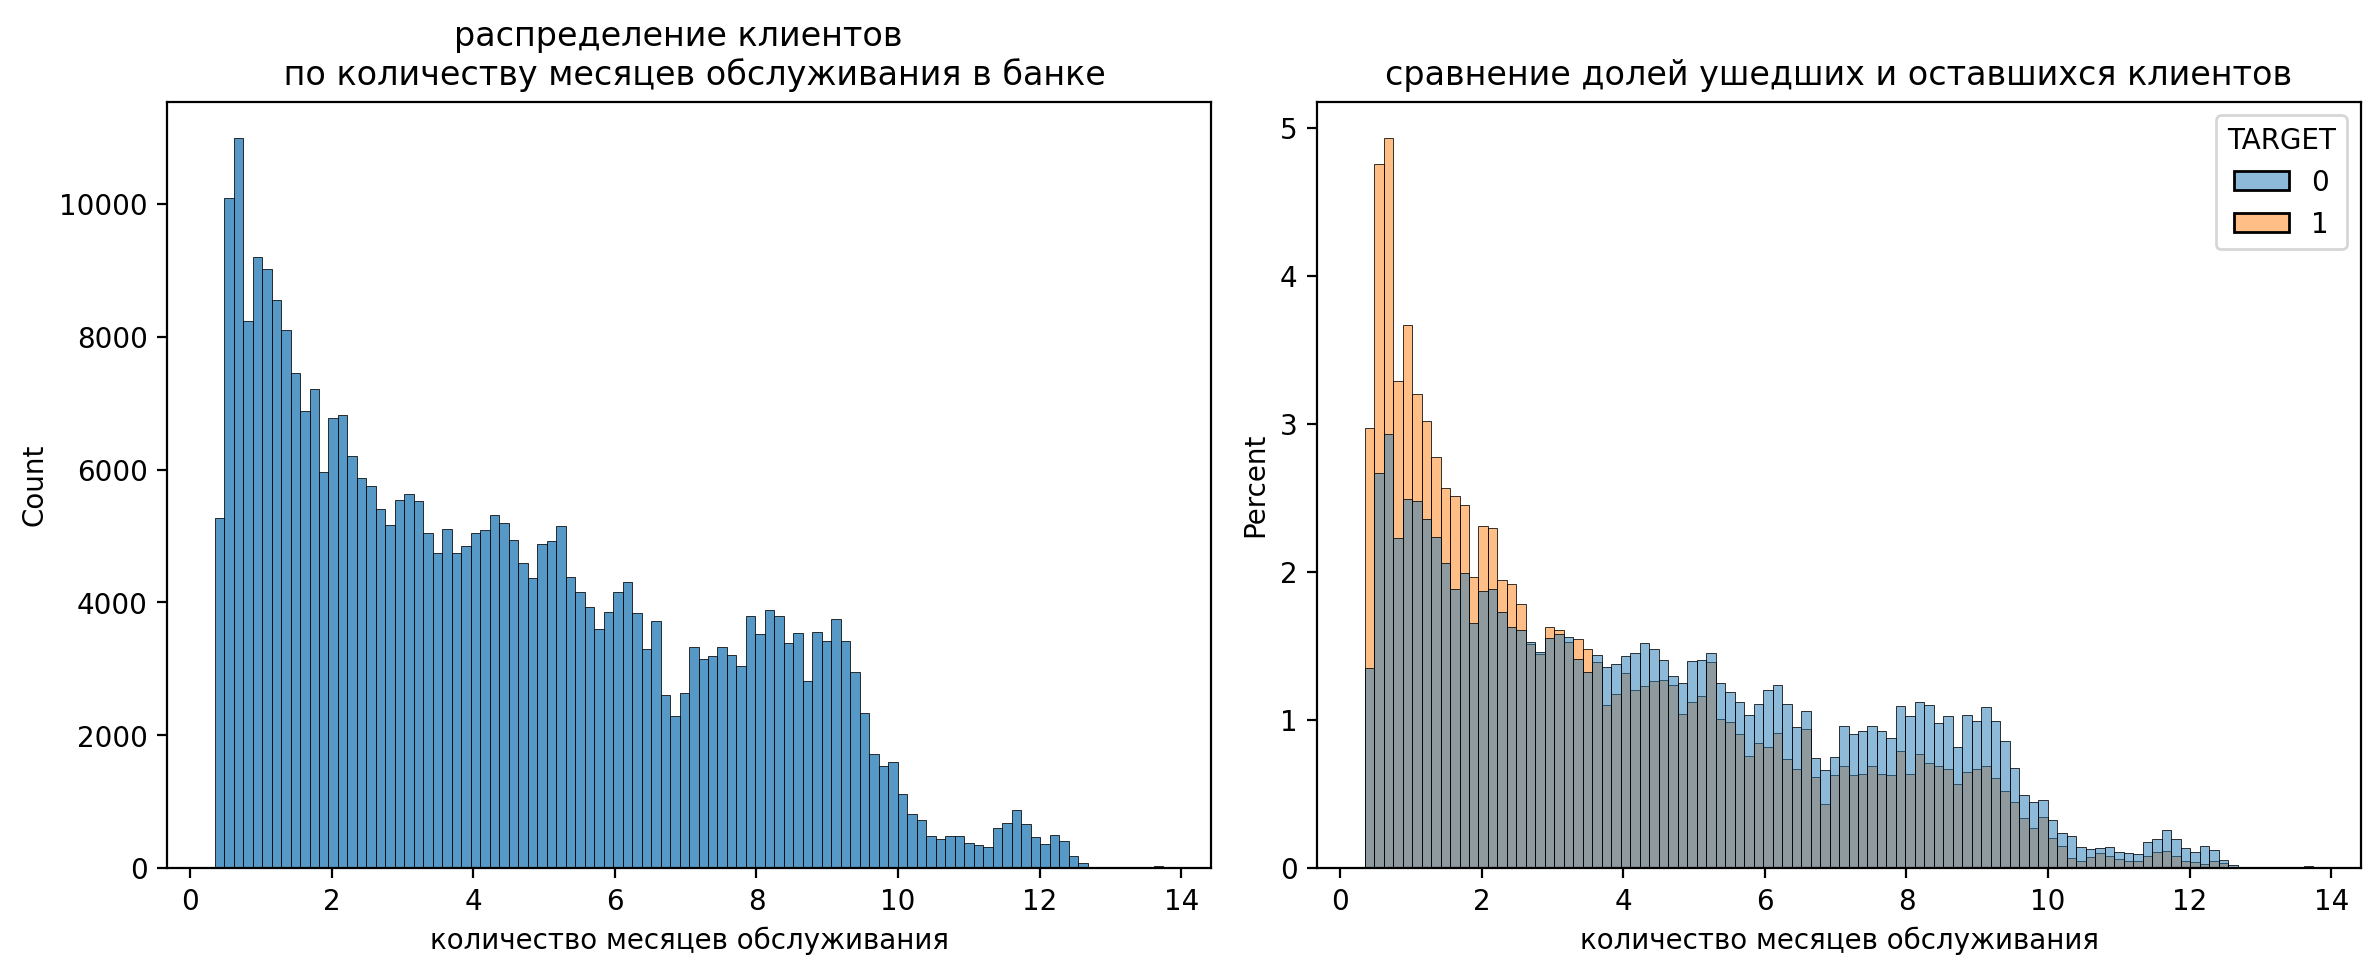

In [28]:
ef.plot_2_hists(df, y,
             'CLNT_SETUP_TENOR', 
             'распределение клиентов  \n по количеству месяцев обслуживания в банке', 
             'количество месяцев обслуживания', 
             log=False)

## распределения по динамике среднемесячных остатков на счетах по разным продуктам

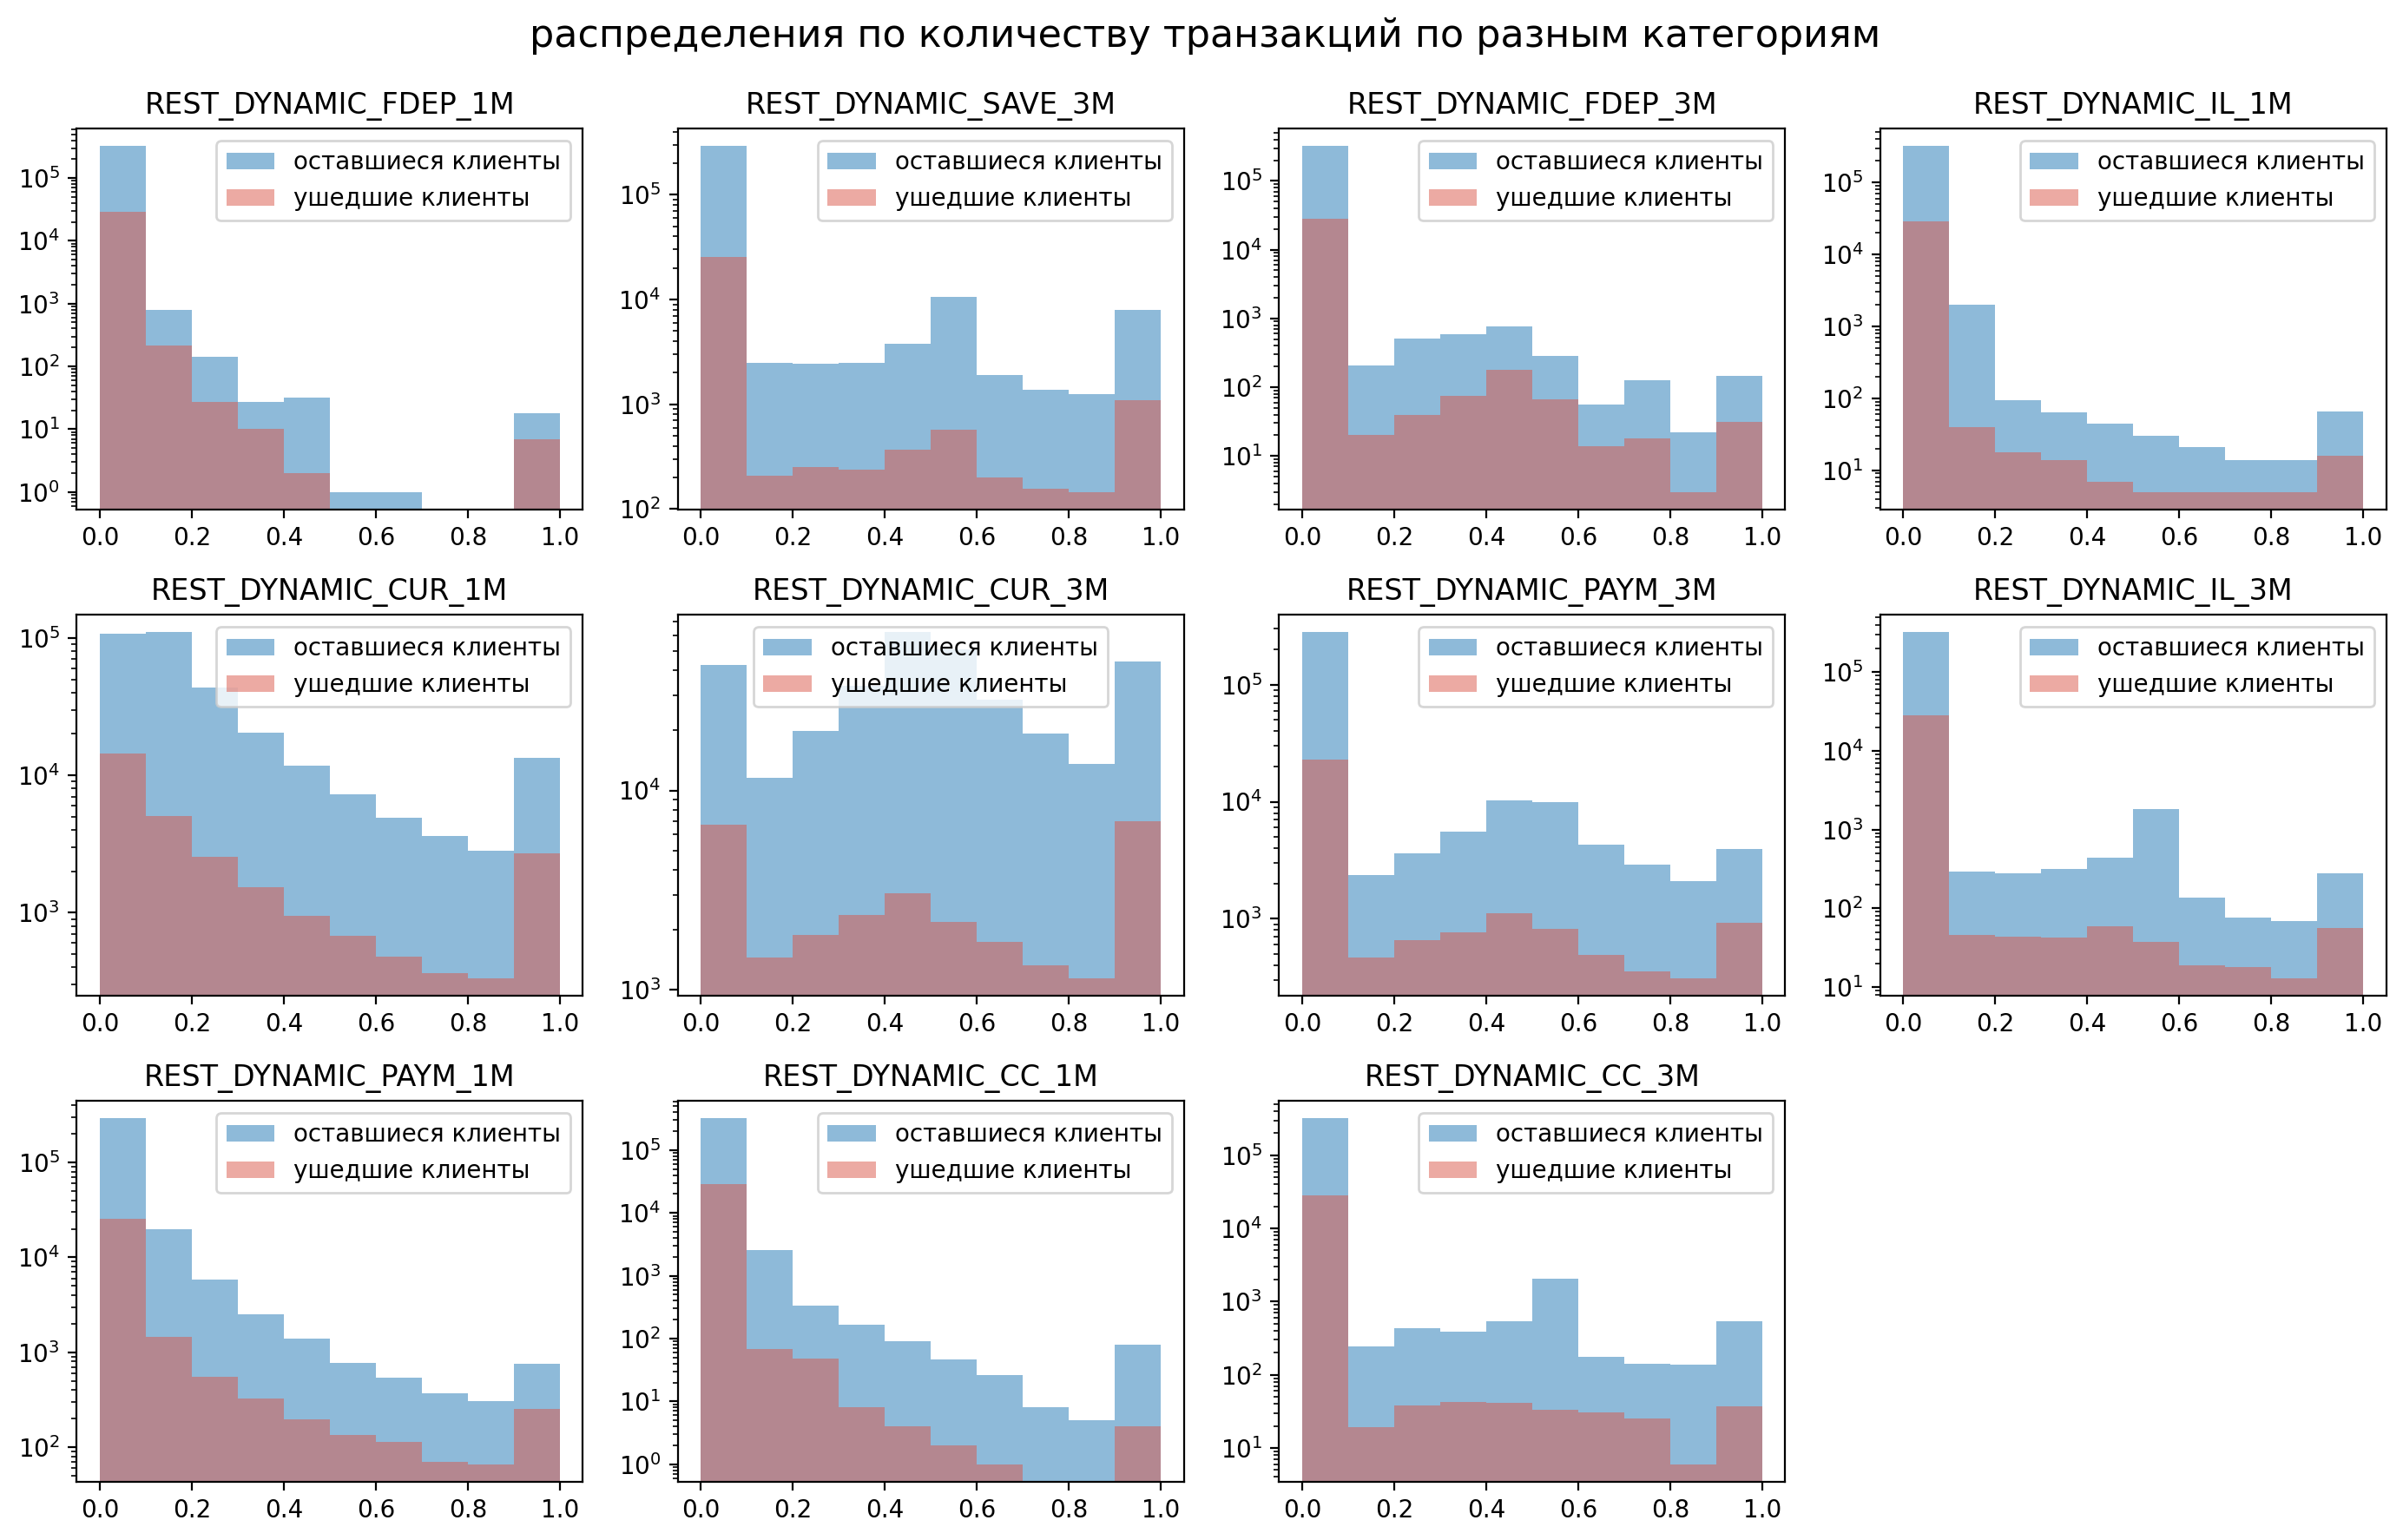

In [29]:
prod_cnt_cols = [i for i in fl_cols if i.startswith('REST_DYNAMIC_')]
fig = plt.figure(figsize=(14,9))
for en, i in enumerate(prod_cnt_cols):
    ax = fig.add_subplot(3, 4, en+1)
    # sns.histplot(df, x=i, ax=ax, kde=True)
    ax.hist(x=df[i][y==0], log=True, alpha=0.5, label='оставшиеся клиенты')
    ax.hist(x=df[i][y==1], log=True, alpha=0.5, color='#db5649', label='ушедшие клиенты')
    ax.set_title(i)
    ax.legend()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle('распределения по количеству транзакций по разным категориям', fontsize=16)
plt.show()

## динамика оборота средств по разным продукта

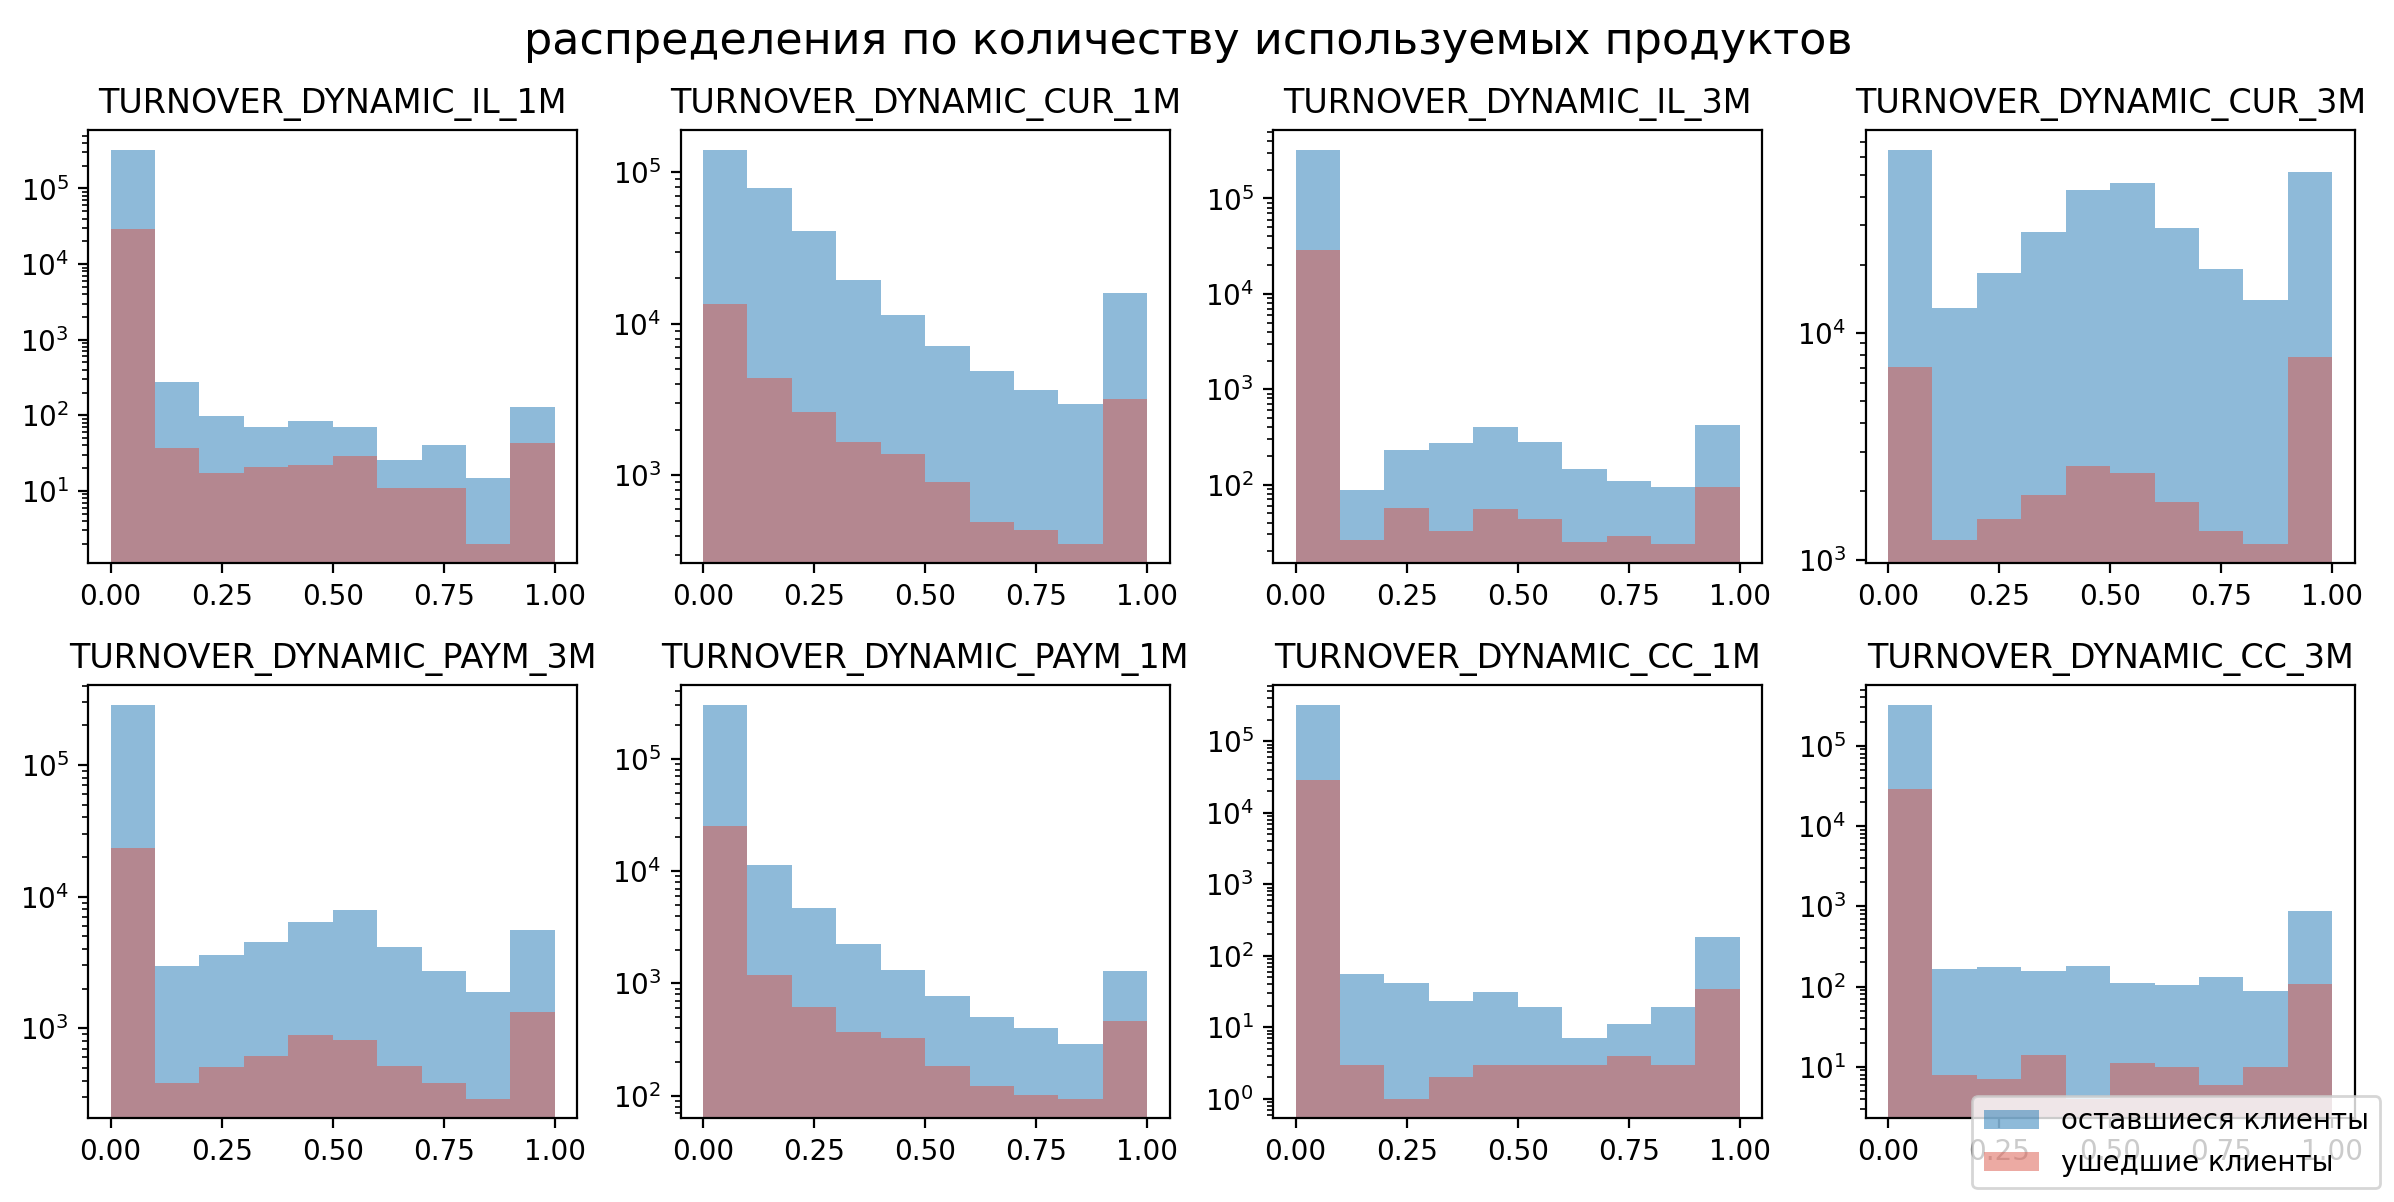

In [30]:
prod_cnt_cols = [i for i in fl_cols if i.startswith('TURNOVER_DY')]
fig = plt.figure(figsize=(12,6))
for en, i in enumerate(prod_cnt_cols):
    ax = fig.add_subplot(2, 4, en+1)
    # sns.histplot(df, x=i, ax=ax, kde=True)
    ax.hist(x=df[i][y==0], log=True, alpha=0.5, label='оставшиеся клиенты')
    ax.hist(x=df[i][y==1], log=True, alpha=0.5, color='#db5649', label='ушедшие клиенты')
    ax.set_title(i)
    # ax.legend()
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle('распределения по количеству используемых продуктов', fontsize=16)
plt.show()

## распределения по количеству используемых продуктов из разных категорий

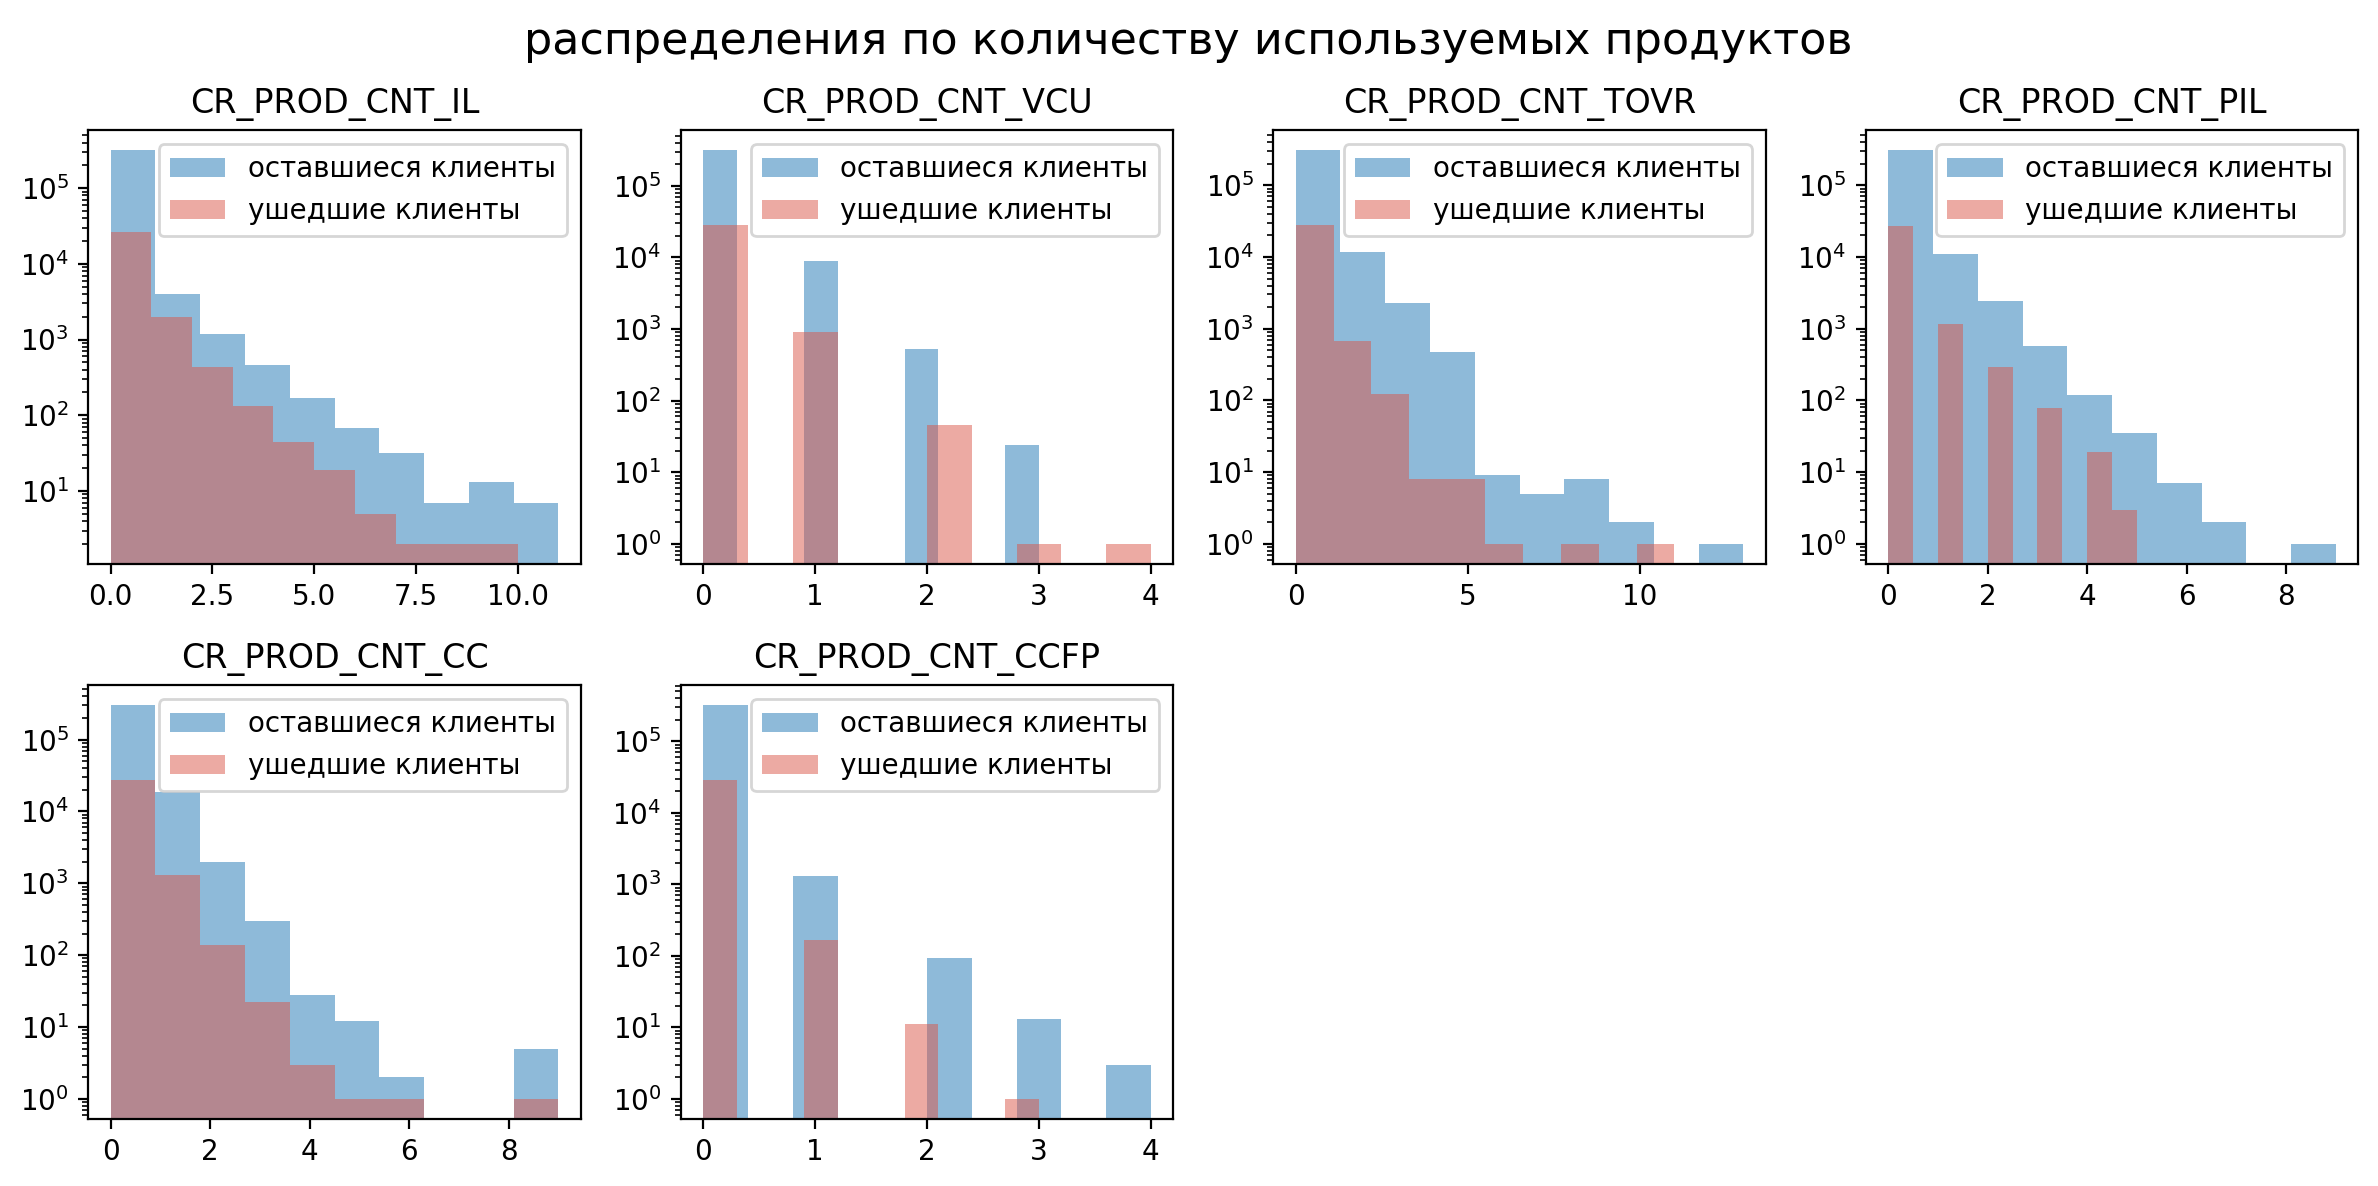

In [31]:
prod_cnt_cols = [i for i in int_cols if i.startswith('CR_')]
fig = plt.figure(figsize=(12,6))
for en, i in enumerate(prod_cnt_cols):
    ax = fig.add_subplot(2, 4, en+1)
    # sns.histplot(df, x=i, ax=ax, kde=True)
    ax.hist(x=df[i][y==0], log=True, alpha=0.5, label='оставшиеся клиенты')
    ax.hist(x=df[i][y==1], log=True, alpha=0.5, color='#db5649', label='ушедшие клиенты')
    ax.set_title(i)
    ax.legend()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle('распределения по количеству используемых продуктов', fontsize=16)
plt.show()

In [32]:
for en, i in enumerate(prod_cnt_cols):
    print(f'{i} уникальные значения:', df[i].unique())

CR_PROD_CNT_IL уникальные значения: [ 0  2  4  1  3  5  6  7 10  9  8 11]
CR_PROD_CNT_VCU уникальные значения: [0 1 2 3 4]
CR_PROD_CNT_TOVR уникальные значения: [ 0  2  1  3  4  5  6  8 11 10  9  7 13]
CR_PROD_CNT_PIL уникальные значения: [0 1 2 3 4 5 6 7 9]
CR_PROD_CNT_CC уникальные значения: [0 1 3 2 4 5 9 6]
CR_PROD_CNT_CCFP уникальные значения: [0 1 2 3 4]


## доли транзакций по различным категориям

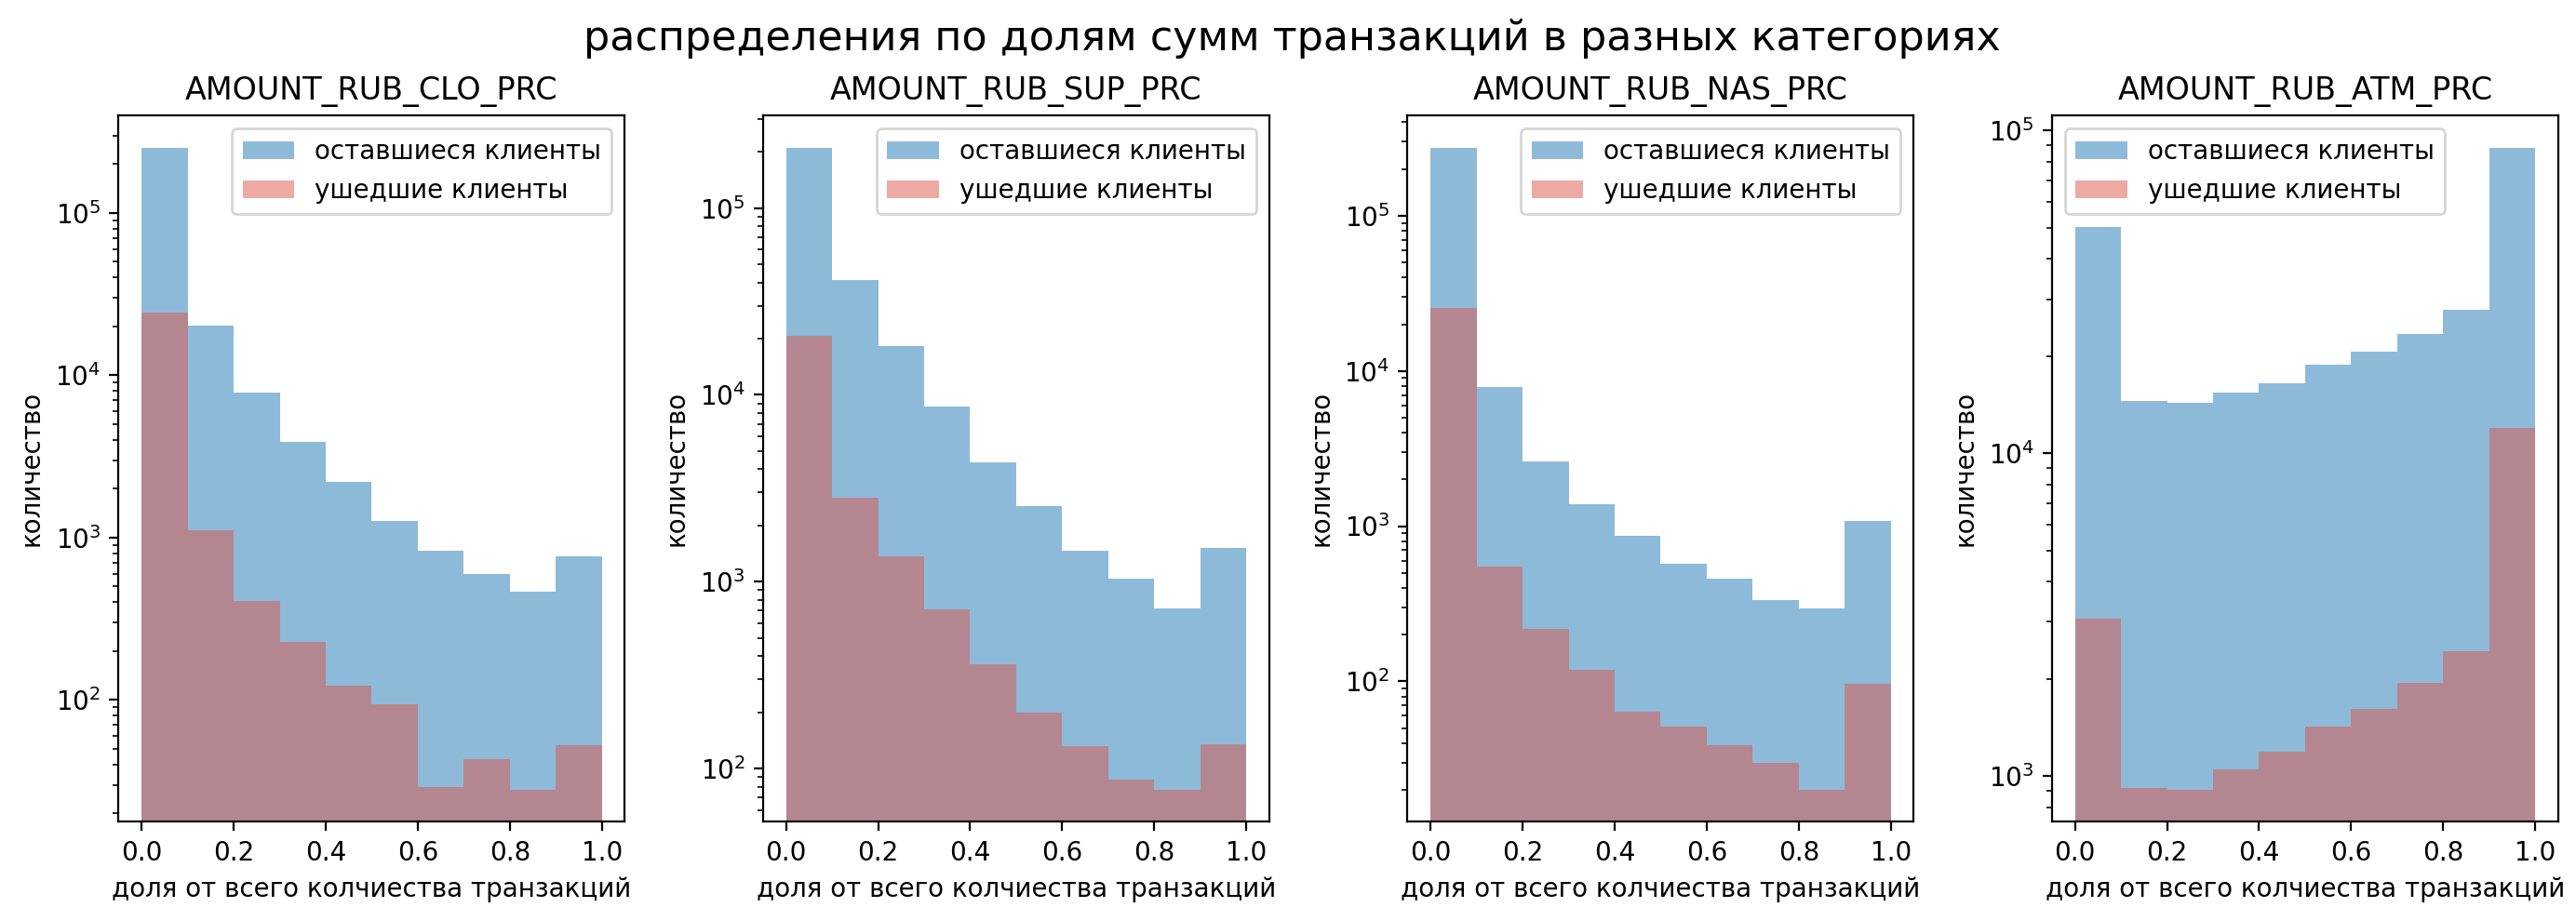

In [33]:
prod_cnt_cols = [i for i in fl_cols if i.startswith('AMOUNT_')]
fig = plt.figure(figsize=(14,5))
for en, i in enumerate(prod_cnt_cols):
    ax = fig.add_subplot(1, 4, en+1)
    # sns.histplot(df, x=i, ax=ax, kde=True)
    ax.hist(x=df[i][y==0], log=True, alpha=0.5, label='оставшиеся клиенты')
    ax.hist(x=df[i][y==1], log=True, alpha=0.5, color='#db5649', label='ушедшие клиенты')
    ax.set_title(i)
    ax.legend()
    ax.set_xlabel('доля от всего колчиества транзакций')
    ax.set_ylabel('количество')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle('распределения по долям сумм транзакций в разных категориях', fontsize=16)
plt.show()

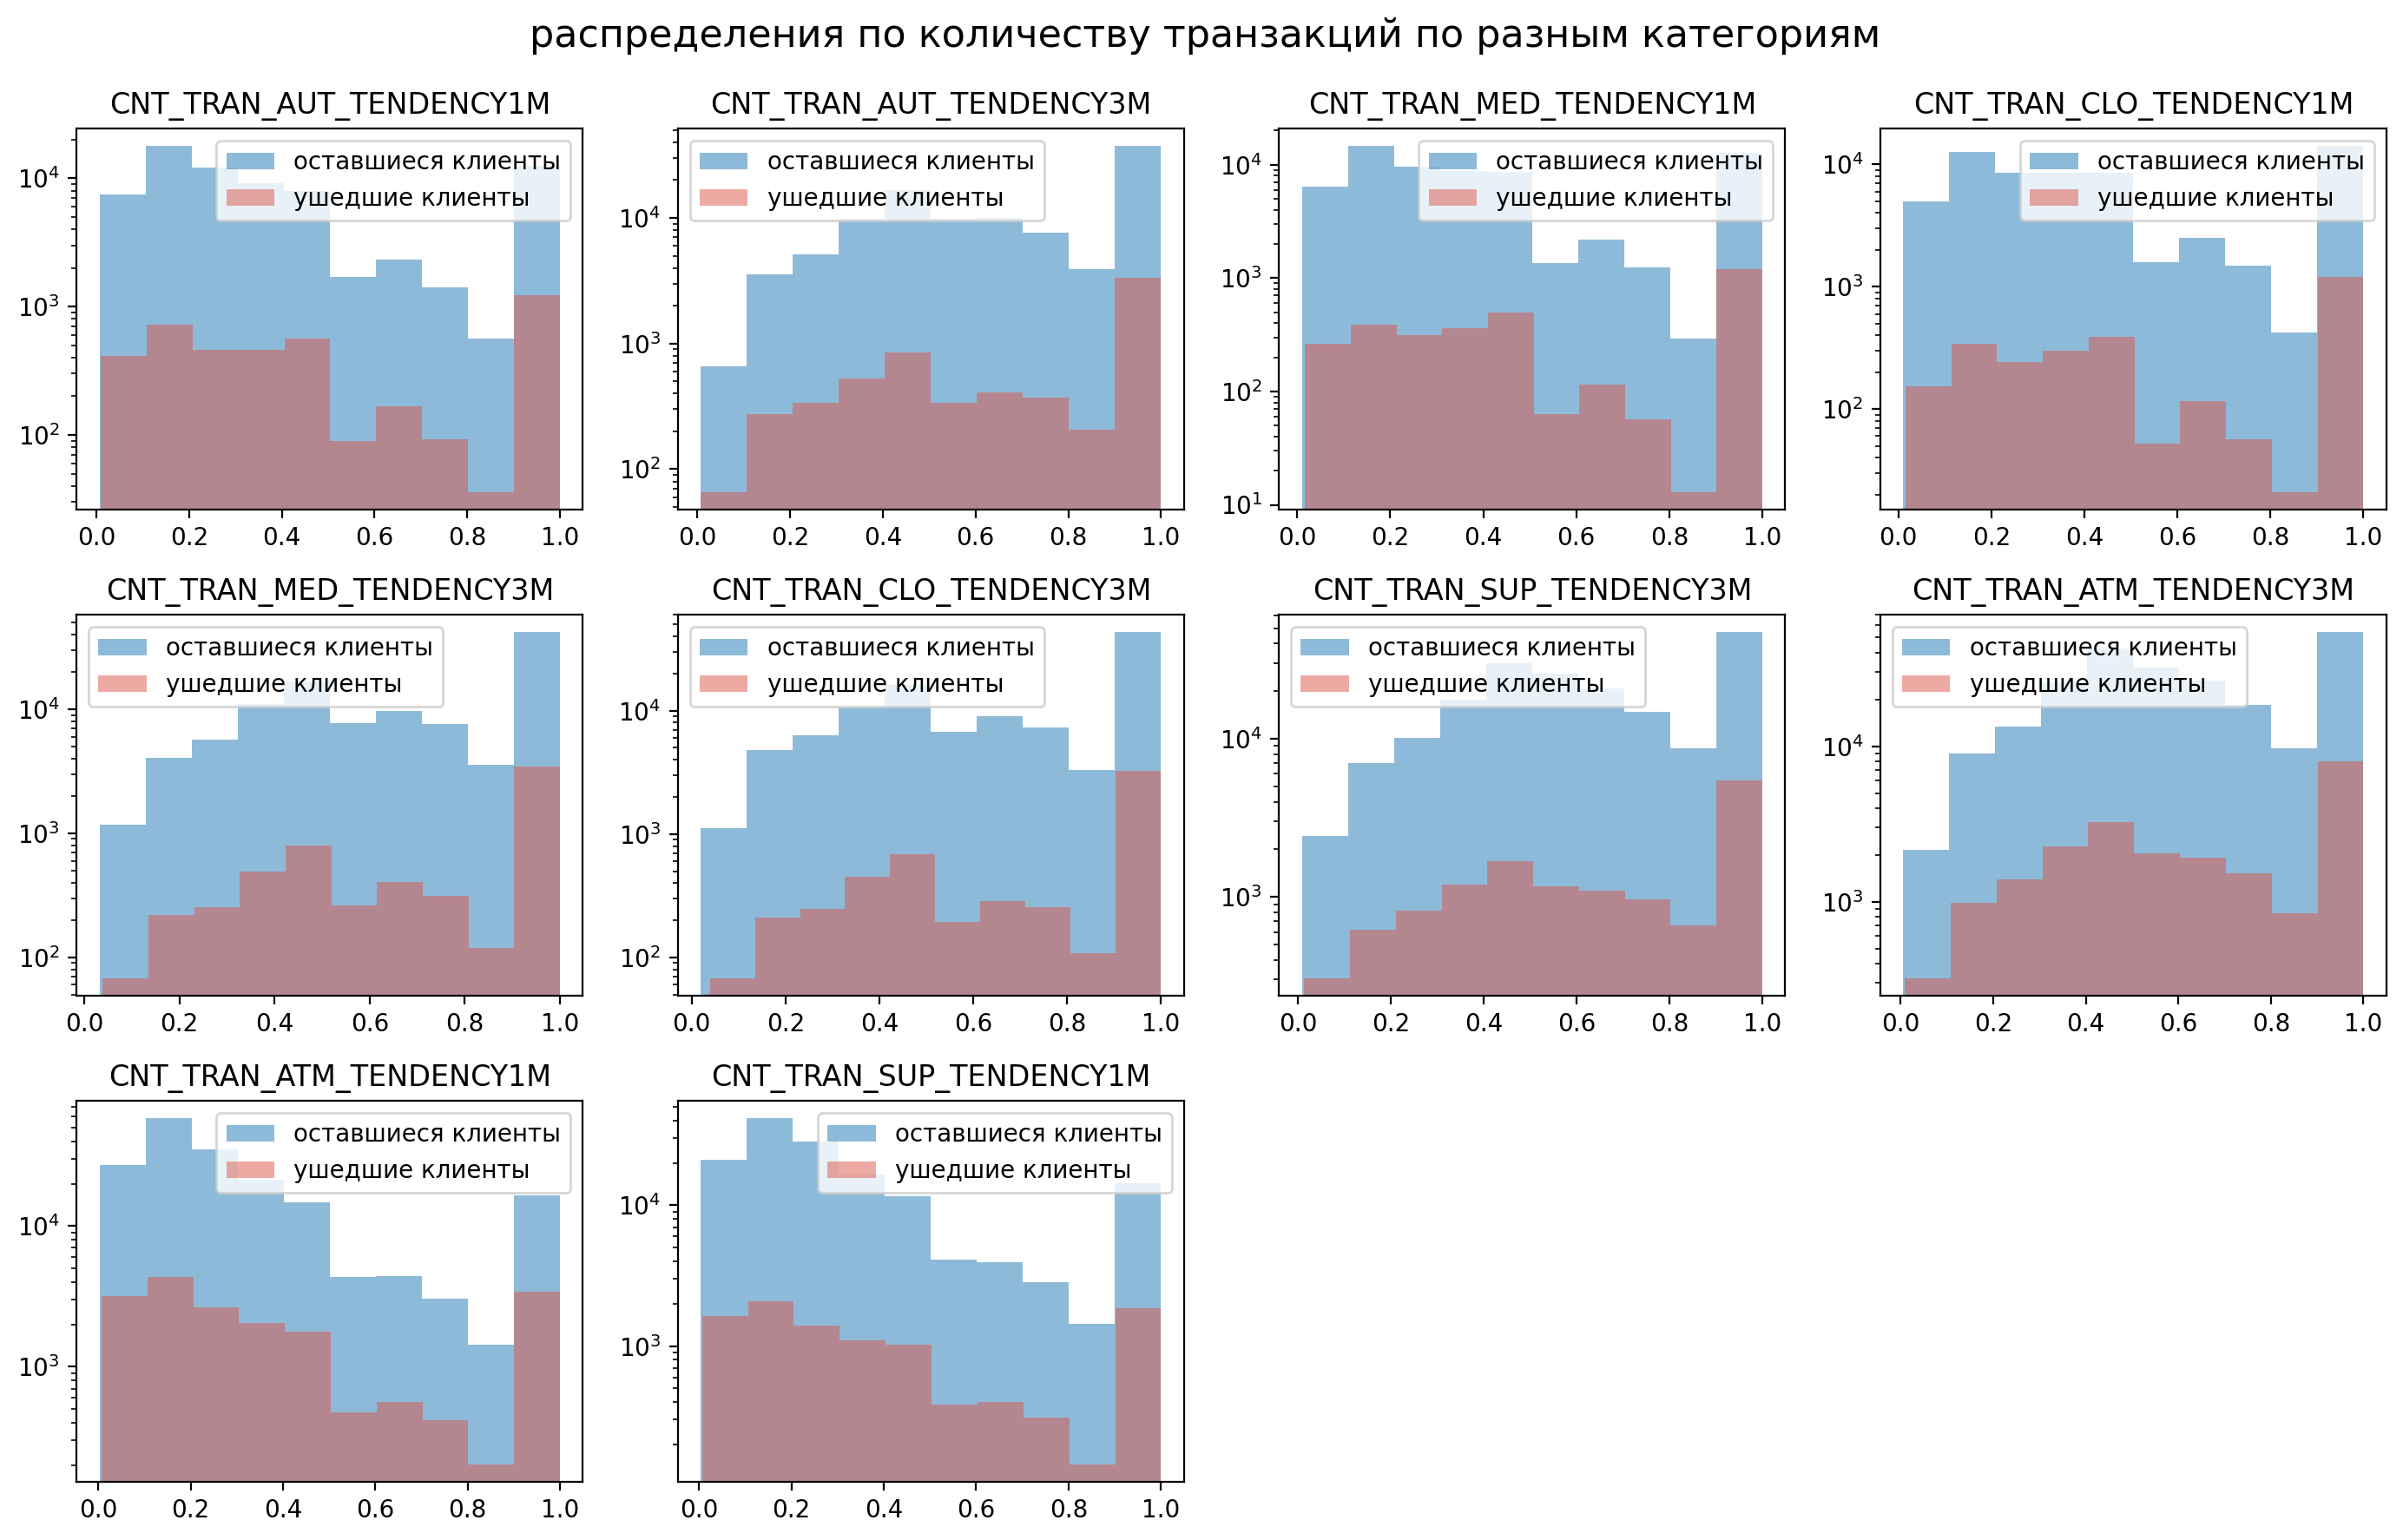

In [34]:
prod_cnt_cols = [i for i in fl_cols if i.startswith('CNT_TRAN_')]
fig = plt.figure(figsize=(14,9))
for en, i in enumerate(prod_cnt_cols):
    ax = fig.add_subplot(3, 4, en+1)
    # sns.histplot(df, x=i, ax=ax, kde=True)
    ax.hist(x=df[i][y==0], log=True, alpha=0.5, label='оставшиеся клиенты')
    ax.hist(x=df[i][y==1], log=True, alpha=0.5, color='#db5649', label='ушедшие клиенты')
    ax.set_title(i)
    ax.legend()
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.suptitle('распределения по количеству транзакций по разным категориям', fontsize=16)
plt.show()

# распределение по таргету

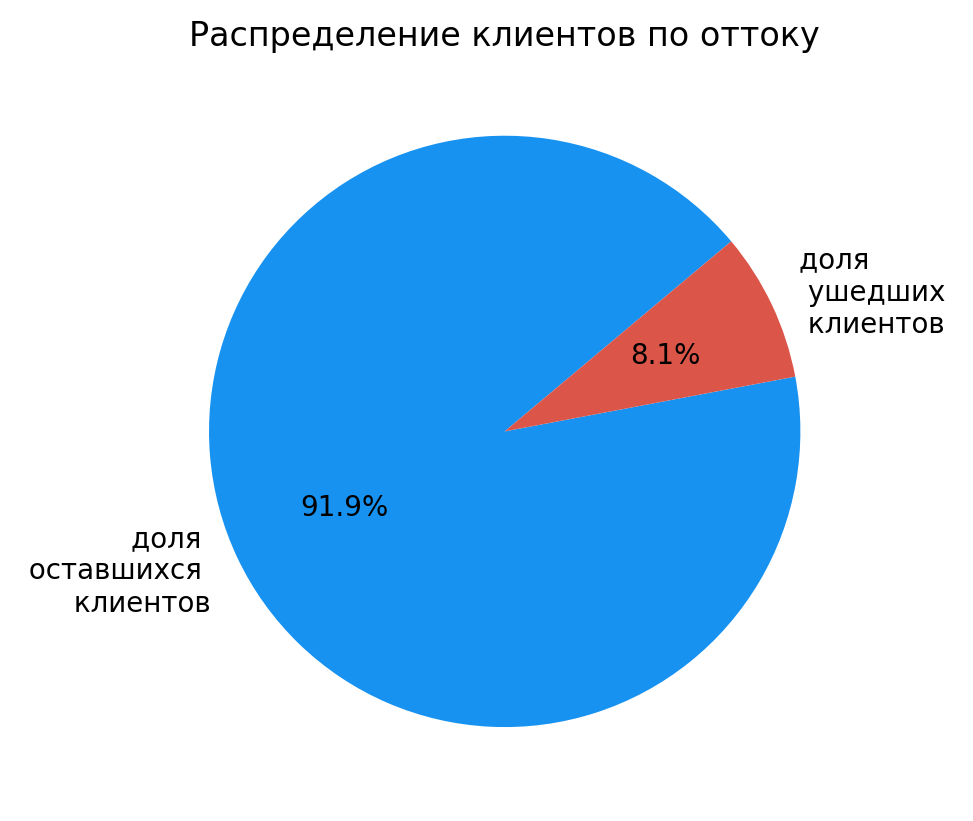

In [35]:
y_counts = y.value_counts()
plt.pie(y_counts, labels=('доля \n оставшихся \n клиентов', 'доля \n ушедших \n клиентов'),
        autopct='%1.1f%%', colors=['#1792f1', '#db5649'], startangle=40
        )
plt.title('Распределение клиентов по оттоку')
plt.show()

## доля оттока по возрастным группам

- среди возрастных групп клиенты млажше 30 лет уходят чаще всего

In [36]:
age_grps = pd.cut(df['AGE']/12, [13,20,30,40,50,60,100], right=True)
age_df = pd.concat((age_grps, y), axis=1)
age_df.groupby(by='AGE').mean()

,TARGET
AGE,
"(13, 20]",0.144321
"(20, 30]",0.097526
"(30, 40]",0.075957
"(40, 50]",0.070363
"(50, 60]",0.070660
"(60, 100]",0.074349
